<p align="center">
  <img src="https://upload.wikimedia.org/wikipedia/en/4/47/FC_Barcelona_%28crest%29.svg" width="200" height="200">
</p>

**Anggota Kelompok Dadsak**
1. Sayyid Thariq Gilang Muttaqien (2306275714)
2. Rania Berliana
3. Rama Aditya Harmono
4. Bon bon

# 🏆 Proyek Akhir KASDAD 25/26  
## Topik: La Liga Football Matches (LFM)
---

### Pendahuluan
---

Sepak bola bukan hanya permainan 90 menit, tetapi juga rangkaian peristiwa yang kompleks — mulai dari operan, tembakan, hingga strategi pertahanan yang menentukan hasil akhir pertandingan.  
Dalam konteks **La Liga**, salah satu liga paling kompetitif di dunia, setiap aksi di lapangan menciptakan jejak data yang merekam dinamika taktik dan performa tim.

Dataset **La Liga Football Matches (LFM)** menyediakan dua sumber utama:
1. **Matches Dataset** — berisi informasi umum tiap pertandingan, termasuk hasil, skor, penguasaan bola (*ball possession*), serta detail manajer, wasit, dan stadion.
2. **Events Dataset** — berisi data granular dari setiap aksi dalam pertandingan (seperti *pass, shot, dribble, tackle, interception,* dan *foul*).

Melalui kedua dataset ini, proyek ini bertujuan untuk:
- Menggali **insight taktis dan performa tim** berdasarkan data pertandingan dan event.  
- Membangun **model klasifikasi** untuk memprediksi hasil pertandingan (`Result`: Win/Draw/Lose).  
- Membangun **model regresi** untuk memprediksi tingkat penguasaan bola (`Poss`).  
- Melakukan **clustering** untuk mengelompokkan pertandingan berdasarkan gaya bermain atau karakteristik statistik.

### Tujuan Analisis
---

1. Siapakah pemain Barcelona yang kerap menjadi pemecah kebuntuan tim (ketika hasil masih defisit atau seri bagi tim yang bersangkutan) dalam dataset ini?
2. Apakah suatu formasi tertentu cenderung meng-counter formasi tim tertentu? Hubungkan dengan berbagai hal, misalnya pergerakan ofensif dan pengerakan defensif tim.
3. Tentukan gaya permainan tim mayoritas yang digunakan oleh Barcelona dari tahun ke tahun dari data yang ada. (Beberapa playstyle yang terkenal seperti: Possession Game, Quick Counter, Long Ball Counter, Out Wide, Long Ball; di luar ini, juga banyak, bisa dieksplorasi lebih lanjut)
4. Bagaimanakah pola defensif tim Barcelona dari tahun ke tahun, apakah ada penyesuaian pola jika menghadapi tim-tim tertentu?
5. . Siapa pemain yang paling sering menjadi "creator" sebelum shot (pass langsung sebelum shot)?


### Relevansi
---

Proyek ini tidak hanya menggabungkan analisis statistik dan machine learning, tetapi juga memanfaatkan **domain knowledge sepak bola** untuk memahami data dalam konteks taktik dan strategi.  
Dengan demikian, hasil analisis diharapkan dapat menjawab pertanyaan mendasar dalam analisis performa olahraga, seperti:
> *Apakah dominasi penguasaan bola selalu berujung pada kemenangan?*  
> *Apa ciri khas permainan Barcelona dari tahun ke tahun menurut data?*


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as scp
from collections import Counter

pd.set_option('display.max_rows', None)     # tampilkan semua baris
pd.set_option('display.max_columns', None)  # tampilkan semua kolom
pd.set_option('display.width', None)        # biar nggak wrap otomatis
pd.set_option('display.max_colwidth', None) # biar kolom teks panjang tampil penuh

In [4]:

# Load dataset
path = 'train.csv'
test_path = 'test.csv'
events_path = 'events_train.csv'
startingxi = 'startingxi.csv'
positions = 'position_guide.csv'

match_data = pd.read_csv(path)
events_data = pd.read_csv(events_path)
starting_xi = pd.read_csv(startingxi)
positions_guide = pd.read_csv(positions)
test_data = pd.read_csv(test_path)

C:\Users\sayyi\AppData\Local\Temp\ipykernel_24900\1089511551.py:9: DtypeWarning: Columns (24,38,52,58,59,60,61,62,63,64,65,69,70,71,72,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,99,100) have mixed types. Specify dtype option on import or set low_memory=False.
  events_data = pd.read_csv(events_path)


In [5]:
events_data['match_id'] = events_data['match_id'].astype(int)
match_data['match_id'] = match_data['match_id'].astype(int)

# pilih hanya kolom match_id + home_team.home_team_name lalu rename untuk kemudahan
match_home = match_data[['match_id', 'home_team.home_team_name','away_team.away_team_name']].rename(
    columns={'home_team.home_team_name': 'home_team_name',
             'away_team.away_team_name': 'away_team_name'}

)

# merge ke events (left join agar semua events tetap ada)
events_merged = events_data.merge(match_home, on='match_id', how='left')

# quick check
print(events_merged[['match_id','home_team_name','away_team_name']].tail(50))

        match_id home_team_name away_team_name
328625   3773547      Barcelona        Osasuna
328626   3773547      Barcelona        Osasuna
328627   3773547      Barcelona        Osasuna
328628   3773547      Barcelona        Osasuna
328629   3773547      Barcelona        Osasuna
328630   3773547      Barcelona        Osasuna
328631   3773547      Barcelona        Osasuna
328632   3773547      Barcelona        Osasuna
328633   3773547      Barcelona        Osasuna
328634   3773547      Barcelona        Osasuna
328635   3773547      Barcelona        Osasuna
328636   3773547      Barcelona        Osasuna
328637   3773547      Barcelona        Osasuna
328638   3773547      Barcelona        Osasuna
328639   3773547      Barcelona        Osasuna
328640   3773547      Barcelona        Osasuna
328641   3773547      Barcelona        Osasuna
328642   3773547      Barcelona        Osasuna
328643   3773547      Barcelona        Osasuna
328644   3773547      Barcelona        Osasuna
328645   3773

> ## 1.) Exploratory Data Analysis (EDA) 

> helper functions

In [6]:
def missing_values_info(df,arr):
    for col in df:
        missing = df[col].isna().sum()
        arr.append([col, missing, (missing/len(events_data))*100])

missing_info = []
#sortir informasi missing values
missing_values_info(events_merged, missing_info)
missing_df = pd.DataFrame(missing_info, columns=['Column', 'Missing Values', 'Percentage'])
missing_df = missing_df.sort_values(by='Missing Values', ascending=False)
print(missing_df)

                               Column  Missing Values  Percentage
98             goalkeeper.success_out          328675  100.000000
92                goalkeeper.lost_out          328674   99.999696
100           goalkeeper.lost_in_play          328674   99.999696
99               player_off.permanent          328674   99.999696
89                      shot.redirect          328674   99.999696
95         goalkeeper.success_in_play          328673   99.999391
97               shot.follows_dribble          328672   99.999087
90                 shot.saved_to_post          328669   99.998174
87   goalkeeper.shot_saved_off_target          328669   99.998174
86              shot.saved_off_target          328669   99.998174
91      goalkeeper.shot_saved_to_post          328668   99.997870
88             goalkeeper.punched_out          328666   99.997262
85                   dribble.no_touch          328666   99.997262
96                   block.save_block          328662   99.996045
94        

In [7]:
def drop_cols_by_names (df, col_names):
    return df.drop(columns=col_names)

> membuat klasifikasi untuk kolom - kolom pada dataset events berdasarkan jenis event sepeti `pass`, `shot`, `dribble`, serta `saved` yg diambil dari `goalkeeper`.

In [8]:
goalkeeper_cols = ['goalkeeper.success_out','goalkeeper.lost_out','shot.redirect','goalkeeper.lost_in_play','goalkeeper.success_in_play','goalkeeper.shot_saved_off_target','goalkeeper.shot_saved_to_post',
                   'goalkeeper.punched_out','goalkeeper.body_part.name','goalkeeper.technique.name','goalkeeper.outcome.name','goalkeeper.end_location','goalkeeper.position.name','goalkeeper.type.name']
passing_cols = ['pass.miscommunication','pass.deflected','pass.no_touch','pass.cut_back','pass.goal_assist','pass.outswinging','pass.inswinging','pass.through_ball','pass.aerial_won','pass.technique.name',
                'pass.shot_assist','pass.cross','pass.switch','pass.type.name','pass.outcome.name','pass.recipient.name','pass.body_part.name','pass.height.name','pass.angle','pass.end_location']
shoting_cols = ['shot.follows_dribble','shot.saved_off_target','shot.saved_to_post','shot.open_goal','shot.deflected','shot.aerial_won','shot.aerial_won','shot.first_time','shot.technique.name','shot.type.name',
                'shot.end_location','shot.body_part.name','shot.outcome.name']
dribble_cols = ['dribble.outcome.name','dribble.nutmeg','dribble.overrun','dribble.no_touch']


> melakukan pembuangan kolom yang memiliki persentase missing values yang besar serta tidak relevan untuk dilanjukan ke tahap preprocessing dan modeling.

In [9]:
high_col_percent_missing =['goalkeeper.success_out','goalkeeper.lost_out','goalkeeper.lost_in_play','shot.saved_off_target','shot.follows_dribble','shot.saved_off_target','goalkeeper.shot_saved_off_target','goalkeeper.punched_out','dribble.no_touch','pass.cut_back','pass.outswinging',
                           'substitution.replacement.name','substitution.outcome.name',
                           'goalkeeper.body_part.name','goalkeeper.technique.name','out','shot.body_part.name',
                           'pass.recipient.name','pass.body_part.name','pass.height.name','off_camera','shot.first_time','shot.redirect','shot.follows_dribble',
                           'dribble.nutmeg','dribble.overrun','dribble.no_touch','clearance.other','injury_stoppage.in_chain','goalkeeper.position.name',
                           'goalkeeper.type.name','timestamp','type.name','duel.type.name','pass.type.name','id','player.name','related_events',
                           'play_pattern.name','location','pass.angle','pass.end_location','shot.end_location','shot.technique.name','pass.technique.name',
                           'shot.type.name','shot.deflected','pass.shot_assist','pass.cross','pass.switch','pass.through_ball','pass.aerial_won','pass.miscommunication','pass.deflected','pass.no_touch']

copied_df = drop_cols_by_names(events_merged, high_col_percent_missing)

missing_values = []
missing_values_info(copied_df,missing_values)

index_output = list(range(0, len(missing_values)))
(pd.DataFrame(missing_values, columns=['Fitur', '# Missing','% Missing'], index=index_output).sort_values(by=['% Missing'], ascending=False, ignore_index=True))
 


,Fitur,# Missing,% Missing
0,player_off.permanent,328674,99.999696
1,goalkeeper.success_in_play,328673,99.999391
2,shot.saved_to_post,328669,99.998174
3,goalkeeper.shot_saved_to_post,328668,99.997870
4,block.save_block,328662,99.996045
5,foul_won.penalty,328661,99.995740
6,foul_committed.penalty,328655,99.993915
7,shot.open_goal,328651,99.992698
8,ball_recovery.offensive,328651,99.992698
9,pass.straight,328638,99.988743


> Melakukan konversi tipe data pada beberapa kolom yang sesuai dengan tipe data yang diinginkan.


In [10]:
copied_df.dtypes

index                               int64
period                              int64
possession                          int64
duration                          float64
possession_team.name               object
team.name                          object
under_pressure                     object
carry.end_location                 object
dribble.outcome.name               object
duel.outcome.name                  object
50_50.outcome.name                 object
shot.outcome.name                  object
goalkeeper.end_location            object
pass.outcome.name                  object
ball_receipt.outcome.name          object
counterpress                       object
clearance.left_foot                object
clearance.body_part.name           object
clearance.right_foot               object
clearance.head                     object
foul_won.defensive                 object
interception.outcome.name          object
goalkeeper.outcome.name            object
ball_recovery.recovery_failure    

In [11]:
bool_cols = [
    'under_pressure', 'counterpress', 'pass.switch', 'pass.cross', 'pass.goal_assist',
    'pass.shot_assist', 'shot.first_time', 'shot.open_goal', 'shot.one_on_one',
    'clearance.left_foot', 'clearance.right_foot', 'clearance.head',
    'foul_committed.penalty', 'foul_won.penalty'
]

for col in bool_cols:
    events_data[col] = events_data[col].apply(lambda x: 1 if x == True or x == 'TRUE' else 0)

> Melakukan `feature engineering` berdasarkan domain knowledge sepak bola untuk menambah kolom - kolom baru yang dapat membantu dalam analisis dan pemodelan selanjutnya.

In [12]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['shot.outcome.name', 'pass.outcome.name', 'duel.outcome.name','dribble.outcome.name',
            'interception.outcome.name','block.save_block','goalkeeper.shot_saved_to_post','goalkeeper.outcome.name',
            'foul_won.penalty','foul_committed.penalty']
le = LabelEncoder()
for col in cat_cols:
    copied_df[col] = copied_df[col].astype(str).fillna('Unknown')
    copied_df[col] = le.fit_transform(copied_df[col])

copied_df.dtypes


index                               int64
period                              int64
possession                          int64
duration                          float64
possession_team.name               object
team.name                          object
under_pressure                     object
carry.end_location                 object
dribble.outcome.name                int32
duel.outcome.name                   int32
50_50.outcome.name                 object
shot.outcome.name                   int32
goalkeeper.end_location            object
pass.outcome.name                   int32
ball_receipt.outcome.name          object
counterpress                       object
clearance.left_foot                object
clearance.body_part.name           object
clearance.right_foot               object
clearance.head                     object
foul_won.defensive                 object
interception.outcome.name           int32
goalkeeper.outcome.name             int32
ball_recovery.recovery_failure    

In [13]:
copied_df.shape

(328675, 51)

In [14]:
copied_df.tail(100)

,index,period,possession,duration,possession_team.name,team.name,under_pressure,carry.end_location,dribble.outcome.name,duel.outcome.name,50_50.outcome.name,shot.outcome.name,goalkeeper.end_location,pass.outcome.name,ball_receipt.outcome.name,counterpress,clearance.left_foot,clearance.body_part.name,clearance.right_foot,clearance.head,foul_won.defensive,interception.outcome.name,goalkeeper.outcome.name,ball_recovery.recovery_failure,clearance.aerial_won,pass.goal_assist,pass.inswinging,ball_recovery.offensive,shot.aerial_won,shot.open_goal,shot.one_on_one,foul_committed.card.name,block.deflection,match_id,pass.straight,bad_behaviour.card.name,foul_committed.offensive,foul_committed.type.name,foul_committed.advantage,foul_won.advantage,block.offensive,miscontrol.aerial_won,shot.saved_to_post,goalkeeper.shot_saved_to_post,foul_committed.penalty,foul_won.penalty,goalkeeper.success_in_play,block.save_block,player_off.permanent,home_team_name,away_team_name
328575,3937,2,221,0.866364,Barcelona,Barcelona,NaN,"[14.6, 45.6]",2,5,NaN,8,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3773547,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,NaN,1,NaN,Barcelona,Osasuna
328576,3938,2,221,1.311819,Barcelona,Barcelona,NaN,NaN,2,5,NaN,8,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3773547,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,NaN,1,NaN,Barcelona,Osasuna
328577,3939,2,221,NaN,Barcelona,Barcelona,NaN,NaN,2,5,NaN,8,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3773547,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,NaN,1,NaN,Barcelona,Osasuna
328578,3940,2,221,1.415417,Barcelona,Barcelona,NaN,"[34.6, 61.4]",2,5,NaN,8,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3773547,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,NaN,1,NaN,Barcelona,Osasuna
328579,3941,2,221,2.032596,Barcelona,Barcelona,NaN,NaN,2,5,NaN,8,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3773547,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,NaN,1,NaN,Barcelona,Osasuna
328580,3942,2,221,NaN,Barcelona,Barcelona,NaN,NaN,2,5,NaN,8,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3773547,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,NaN,1,NaN,Barcelona,Osasuna
328581,3943,2,221,0.080000,Barcelona,Barcelona,NaN,"[50.4, 33.3]",2,5,NaN,8,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3773547,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,NaN,1,NaN,Barcelona,Osasuna
328582,3944,2,221,1.152364,Barcelona,Barcelona,NaN,NaN,2,5,NaN,8,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3773547,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,NaN,1,NaN,Barcelona,Osasuna
328583,3945,2,221,NaN,Barcelona,Barcelona,NaN,NaN,2,5,NaN,8,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3773547,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,NaN,1,NaN,Barcelona,Osasuna
328584,3946,2,221,1.240049,Barcelona,Barcelona,NaN,"[48.3, 33.2]",2,5,NaN,8,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3773547,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,NaN,1,NaN,Barcelona,Osasuna


### Melakukan understanding data terhadap dataset events

#### helper functions

In [15]:
for col in cat_cols:
    print(f"Value counts for {col}:")
    print(events_data[col].value_counts())
    print()

Value counts for shot.outcome.name:
shot.outcome.name
Off T               648
Saved               549
Blocked             511
Goal                274
Wayward              82
Post                 48
Saved to Post         6
Saved Off Target      6
Name: count, dtype: int64

Value counts for pass.outcome.name:
pass.outcome.name
Incomplete          12680
Out                  1229
Unknown               410
Pass Offside          343
Injury Clearance       79
Name: count, dtype: int64

Value counts for duel.outcome.name:
duel.outcome.name
Success In Play    1001
Won                 717
Lost In Play        579
Lost Out            443
Success Out         100
Name: count, dtype: int64

Value counts for dribble.outcome.name:
dribble.outcome.name
Complete      1727
Incomplete    1218
Name: count, dtype: int64

Value counts for interception.outcome.name:
interception.outcome.name
Won                795
Success In Play    509
Lost In Play       449
Lost Out           226
Success Out         10
Name:

In [16]:
for col in cat_cols:
    print(f"Value counts for {col}:")
    print(copied_df[col].value_counts())
    print()

15,12,9,1,0,11,14

Value counts for shot.outcome.name:
shot.outcome.name
8    326551
2       648
4       549
0       511
1       274
7        82
3        48
6         6
5         6
Name: count, dtype: int64

Value counts for pass.outcome.name:
pass.outcome.name
5    313934
0     12680
2      1229
4       410
3       343
1        79
Name: count, dtype: int64

Value counts for duel.outcome.name:
duel.outcome.name
5    325835
2      1001
4       717
0       579
1       443
3       100
Name: count, dtype: int64

Value counts for dribble.outcome.name:
dribble.outcome.name
2    325730
0      1727
1      1218
Name: count, dtype: int64

Value counts for interception.outcome.name:
interception.outcome.name
5    326686
4       795
2       509
0       449
1       226
3        10
Name: count, dtype: int64

Value counts for block.save_block:
block.save_block
1    328662
0        13
Name: count, dtype: int64

Value counts for goalkeeper.shot_saved_to_post:
goalkeeper.shot_saved_to_post
1    328668
0         7
Name: co

(15, 12, 9, 1, 0, 11, 14)

In [17]:
def is_barca(name: str) -> bool:
    return isinstance(name,str) and ('barcelona' in name.lower())

matches_barca = match_data[
    match_data['home_team.home_team_name'].apply(is_barca) |
    match_data['away_team.away_team_name'].apply(is_barca)
].copy()

#### understanding data startingxi.csv dan positions_guide.csv

In [18]:
# starting xi for team.name 'Barcelona'
starting_xi_barca = starting_xi[starting_xi['team.name'].apply(is_barca)].copy()
starting_xi_barca = starting_xi_barca.drop_duplicates(subset=['match_id', 'team.name']).reset_index(drop=True)
starting_xi_barca.head(5)

pos_cols = [c for c in starting_xi.columns if c.startswith('pos')]

rows = []
for _, r in starting_xi_barca.iterrows():
    for i in range(1, 26):
        pcol = f'pos{i}'
        player = r.get(pcol, None)
        if pd.notna(player) and str(player).strip() != '':
            rows.append({
                'match_id': r['match_id'],
                'team': r['team.name'],
                'position': i,
                'player': player,
            })

barca_starting_long = pd.DataFrame(rows)


In [19]:
positions_guide_copy = drop_cols_by_names(positions_guide,col_names='Position Name')
positions_guide_copy.rename(columns={'Position Abbreviation':'Position Name'}, inplace=True)
positions_guide_copy = positions_guide_copy.rename(columns={'Position Number': 'position', 'Position Name': 'position_name'})

positions_guide_copy.head(25)

barca_starting_long = barca_starting_long.merge(
    positions_guide_copy,
    on='position',
    how='left'
)

barca_starting_long.head(100)

,match_id,team,position,player,position_name
0,303680,Barcelona,1,Marc-André ter Stegen,GK
1,303680,Barcelona,2,Nélson Cabral Semedo,RB
2,303680,Barcelona,3,Gerard Piqué Bernabéu,RCB
3,303680,Barcelona,5,Clément Lenglet,LCB
4,303680,Barcelona,6,Jordi Alba Ramos,LB
5,303680,Barcelona,10,Sergio Busquets i Burgos,CDM
6,303680,Barcelona,13,Sergi Roberto Carnicer,RCM
7,303680,Barcelona,15,Ricard Puig Martí,LCM
8,303680,Barcelona,19,Arturo Erasmo Vidal Pardo,CAM
9,303680,Barcelona,22,Lionel Andrés Messi Cuccittini,RCF


> aggregasi data events berdasarkan match id dan team id untuk mendapatkan kolom - kolom statistik tim pada setiap pertandingan yang nantinya akan digunakan untuk preprocessing dan modeling.

In [20]:
copied_df['dribble.successful'] = copied_df['dribble.outcome.name'].apply(lambda x: 1 if x == 1 else 0)
copied_df['shot.outcome.goal'] = copied_df['shot.outcome.name'].apply(lambda x: 1 if x == 1 else 0)
copied_df['interception.outcome.positive'] = copied_df['interception.outcome.name'].apply(lambda x: 1 if x == 2 or x == 4 else 0)
copied_df['goalkeeper.outcome.positive'] = copied_df['goalkeeper.outcome.name'].apply(lambda x: 1 if x in [15,12,9,1,0,11,14] else 0)
copied_df['total_clearance'] = copied_df[['clearance.left_foot', 'clearance.right_foot', 'clearance.head']].sum(axis=1)
copied_df['foul_won.penalty'] = copied_df['foul_won.penalty'].apply(lambda x: 1 if x == 1 else 0)
copied_df['foul_committed.penalty'] = copied_df['foul_committed.penalty'].apply(lambda x: 1 if x == 1 else 0)

> membuat fitur - fitur statistik untuk team `home` dan `away` berdasarkan hasil agregasi data events sebelumnya.

In [21]:
team_candidates = ['possession_team.name']
team_col = next((c for c in team_candidates if c in copied_df.columns), None)

df = copied_df.copy()
df['_team_norm'] = df[team_col].astype(str).str.strip().str.lower()
df['_home_norm'] = df['home_team_name'].astype(str).str.strip().str.lower()
df['_away_norm'] = df['away_team_name'].astype(str).str.strip().str.lower()

home_events = df[df['_team_norm'] == df['_home_norm'].copy()]
away_events = df[df['_team_norm'] == df['_away_norm'].copy()]
print(f"Home events: {len(home_events)}, Away events: {len(away_events)}")


Home events: 171260, Away events: 157415


> klasifikasi events `positive` dan `negative` berdasarkan jenis event pada dataset `copied_df` yang sudah dilakukan agregasi sebelumnya.

In [22]:
copied_df['event_positive'] = (
    copied_df['pass.goal_assist'] + 
    copied_df['shot.outcome.goal'] + 
    copied_df['dribble.successful'] + 
    copied_df['interception.outcome.positive'] + 
    copied_df['goalkeeper.outcome.positive'] + 
    copied_df['foul_won.penalty']
)

copied_df['event_negative'] = (
    copied_df['foul_committed.penalty'] +
    (1 - copied_df['dribble.successful']) + 
    (copied_df['pass.outcome.name'] != 0).astype(int)  # jika 0 = sukses
)


In [23]:
agg_cols = [
    'event_positive', 'event_negative',
    'dribble.successful', 'pass.goal_assist', 'shot.outcome.goal',
    'goalkeeper.outcome.positive', 'interception.outcome.positive',
    'foul_won.penalty', 'foul_committed.penalty', 'total_clearance'
]

agg_home = copied_df.groupby(['match_id', 'home_team_name'])[agg_cols].sum().reset_index()
agg_away = copied_df.groupby(['match_id', 'away_team_name'])[agg_cols].sum().reset_index()

agg_home = agg_home.add_prefix('home_')
agg_away = agg_away.add_prefix('away_')

# gabungkan berdasarkan match_id
agg_match = pd.merge(
    agg_home, agg_away, left_on='home_match_id', right_on='away_match_id', how='outer', suffixes=('', '_y')
)
agg_match = agg_match.rename(columns={'home_match_id': 'match_id'})


In [24]:
agg_match['pos_event_diff'] = agg_match['home_event_positive'] - agg_match['away_event_positive']
agg_match['neg_event_diff'] = agg_match['home_event_negative'] - agg_match['away_event_negative']

agg_match['attack_efficiency_home'] = agg_match['home_shot.outcome.goal'] / (agg_match['home_event_positive'] + 1e-5)
agg_match['attack_efficiency_away'] = agg_match['away_shot.outcome.goal'] / (agg_match['away_event_positive'] + 1e-5)

agg_match['defense_efficiency_home'] = agg_match['home_goalkeeper.outcome.positive'] / (agg_match['home_event_negative'] + 1e-5)
agg_match['defense_efficiency_away'] = agg_match['away_goalkeeper.outcome.positive'] / (agg_match['away_event_negative'] + 1e-5)
agg_match.head(10)

,match_id,home_home_team_name,home_event_positive,home_event_negative,home_dribble.successful,home_pass.goal_assist,home_shot.outcome.goal,home_goalkeeper.outcome.positive,home_interception.outcome.positive,home_foul_won.penalty,home_foul_committed.penalty,home_total_clearance,away_match_id,away_away_team_name,away_event_positive,away_event_negative,away_dribble.successful,away_pass.goal_assist,away_shot.outcome.goal,away_goalkeeper.outcome.positive,away_interception.outcome.positive,away_foul_won.penalty,away_foul_committed.penalty,away_total_clearance,pos_event_diff,neg_event_diff,attack_efficiency_home,attack_efficiency_away,defense_efficiency_home,defense_efficiency_away
0,9742,Barcelona,6,11021,18,3,3,10,26,3719,3719,29,9742,Levante UD,6,11021,18,3,3,10,26,3719,3719,29,0,0,0.499999,0.499999,0.000907,0.000907
1,9754,Real Sociedad,10,10908,16,5,6,7,15,3688,3688,27,9754,Barcelona,10,10908,16,5,6,7,15,3688,3688,27,0,0,0.599999,0.599999,0.000642,0.000642
2,9765,Real Betis,10,11443,5,5,5,8,23,3868,3868,13,9765,Barcelona,10,11443,5,5,5,8,23,3868,3868,13,0,0,0.5,0.5,0.000699,0.000699
3,9774,Barcelona,4,10345,15,2,3,10,25,3511,3511,48,9774,Deportivo Alavés,4,10345,15,2,3,10,25,3511,3511,48,0,0,0.749998,0.749998,0.000967,0.000967
4,9783,Espanyol,4,9583,24,2,2,5,22,3263,3263,48,9783,Barcelona,4,9583,24,2,2,5,22,3263,3263,48,0,0,0.499999,0.499999,0.000522,0.000522
5,9794,Barcelona,0,10381,15,0,0,13,38,3527,3527,21,9794,Getafe,0,10381,15,0,0,13,38,3527,3527,21,0,0,0.0,0.0,0.001252,0.001252
6,9799,Eibar,2,10766,11,True,2,7,34,3655,3655,33,9799,Barcelona,2,10766,11,True,2,7,34,3655,3655,33,0,0,0.999995,0.999995,0.000650,0.000650
7,9811,Barcelona,10,10452,22,5,7,14,21,3540,3540,25,9811,Girona,10,10452,22,5,7,14,21,3540,3540,25,0,0,0.699999,0.699999,0.001339,0.001339
8,9827,Las Palmas,0,9841,18,0,2,9,12,3334,3333,28,9827,Barcelona,0,9841,18,0,2,9,12,3334,3333,28,0,0,200000.0,200000.0,0.000915,0.000915
9,9837,Barcelona,0,11723,24,0,1,10,28,3974,3974,23,9837,Atlético Madrid,0,11723,24,0,1,10,28,3974,3974,23,0,0,100000.0,100000.0,0.000853,0.000853


In [25]:
ev = copied_df.copy()

team_col = next((c for c in ['possession_team.name', 'team.name', 'team', 'possession_team'] if c in ev.columns), None)
if team_col is None:
    raise ValueError("Kolom team tidak ditemukan di events_data.")

ev['_team_norm'] = ev[team_col].astype(str).str.strip().str.lower()
ev['_home_norm'] = ev['home_team_name'].astype(str).str.strip().str.lower()
ev['_away_norm'] = ev['away_team_name'].astype(str).str.strip().str.lower()

ev['is_home'] = ev['_team_norm'] == ev['_home_norm']
ev['is_away'] = ev['_team_norm'] == ev['_away_norm']

ev['is_goal'] = ev['shot.outcome.name'].astype(str).str.contains('goal', case=False, na=False).astype(int)

agg_team = ev.groupby(['match_id', team_col]).agg(
    duration_mean=('duration', 'mean'),
    under_pressure_sum=('under_pressure', 'sum'),
    counterpress_sum=('counterpress', 'sum'),
    successful_passes=('pass.outcome.name', lambda x: (x == 0).sum()),
    successful_dribbles=('dribble.outcome.name', lambda x: (x == 0).sum()),
    interceptions=('interception.outcome.positive', 'sum'),
    goalkeeper_positive=('goalkeeper.outcome.positive', 'sum'),
    total_clearance=('total_clearance', 'sum'),
    foul_committed=('foul_committed.penalty', 'sum'),
    foul_won=('foul_won.penalty', 'sum'),
    goals=('is_goal', 'sum')
).reset_index()

agg_team = agg_team.merge(
    ev[['match_id', team_col, 'is_home', 'is_away']].drop_duplicates(),
    on=['match_id', team_col],
    how='left'
)

agg_home = agg_team[agg_team['is_home']]
agg_away = agg_team[agg_team['is_away']]

aggregated_features = pd.merge(
    agg_home,
    agg_away,
    on='match_id',
    how='outer',
    suffixes=('_home', '_away')
)


ev = events_data.copy()

# tanda goal: cek kolom teks dulu
if 'shot.outcome.name' in ev.columns:
    ev['shot_goal_flag'] = ev['shot.outcome.name'].astype(str).str.contains('goal', case=False, na=False).astype(int)
elif 'shot.outcome.goal' in ev.columns:
    ev['shot_goal_flag'] = ev['shot.outcome.goal'].fillna(0).astype(int)
else:
    ev['shot_goal_flag'] = 0

team_candidates = ['possession_team.name', 'team.name', 'team', 'possession_team']
team_col = next((c for c in team_candidates if c in ev.columns), None)

if team_col is None:
    print("Warning: team column not found in events_data — cannot compute Barcelona goals per match.")
    aggregated_features['shot.outcome.goal.barca'] = 0
    aggregated_features['shot.outcome.goal.nonbarca'] = 0
else:
    ev['is_barca'] = ev[team_col].astype(str).str.contains('barcelona', case=False, na=False)
    ev['is_nonbarca'] = ~ev['is_barca']

    barca_goals_per_match = (
        ev.loc[ev['is_barca'] & (ev['shot_goal_flag'] == 1)]
        .groupby('match_id')['shot_goal_flag']
        .sum()
        .rename('shot.outcome.goal.barca')
        .reset_index()
    )

    nonbarca_goals_per_match = (
        ev.loc[ev['is_nonbarca'] & (ev['shot_goal_flag'] == 1)]
        .groupby('match_id')['shot_goal_flag']
        .sum()
        .rename('shot.outcome.goal.nonbarca')
        .reset_index()
    )

    aggregated_features = (
        aggregated_features
        .merge(barca_goals_per_match, on='match_id', how='left')
        .merge(nonbarca_goals_per_match, on='match_id', how='left')
        .fillna({'shot.outcome.goal.barca': 0, 'shot.outcome.goal.nonbarca': 0})
    )

aggregated_features.head(10)    

,match_id,possession_team.name_home,duration_mean_home,under_pressure_sum_home,counterpress_sum_home,successful_passes_home,successful_dribbles_home,interceptions_home,goalkeeper_positive_home,total_clearance_home,foul_committed_home,foul_won_home,goals_home,is_home_home,is_away_home,possession_team.name_away,duration_mean_away,under_pressure_sum_away,counterpress_sum_away,successful_passes_away,successful_dribbles_away,interceptions_away,goalkeeper_positive_away,total_clearance_away,foul_committed_away,foul_won_away,goals_away,is_home_away,is_away_away,shot.outcome.goal.barca,shot.outcome.goal.nonbarca
0,9742,Barcelona,1.181638,434,54,64,15,18,4,10,2615,2615,0,True,False,Levante UD,1.136273,354,51,54,6,8,6,19,1104,1104,0,False,True,3.0,0.0
1,9754,Real Sociedad,1.263976,468,53,84,10,9,4,17,1861,1861,0,True,False,Barcelona,1.275084,459,52,56,9,6,3,10,1827,1827,0,False,True,4.0,2.0
2,9765,Real Betis,1.217708,331,35,82,3,10,3,8,1761,1761,0,True,False,Barcelona,1.279247,488,67,74,20,13,5,5,2107,2107,0,False,True,5.0,0.0
3,9774,Barcelona,1.273502,422,74,95,16,20,6,31,2697,2697,0,True,False,Deportivo Alavés,1.344273,186,45,78,11,5,4,17,814,814,0,False,True,2.0,1.0
4,9783,Espanyol,0.973971,214,54,79,8,5,2,13,912,912,0,True,False,Barcelona,1.185643,388,68,103,11,17,3,35,2351,2351,0,False,True,1.0,1.0
5,9794,Barcelona,1.302541,384,74,109,12,27,5,20,2824,2824,0,True,False,Getafe,1.277433,129,25,76,3,11,8,1,703,703,0,False,True,0.0,0.0
6,9799,Eibar,1.234258,333,52,91,7,20,3,28,1768,1768,0,True,False,Barcelona,1.326094,332,50,97,9,14,4,5,1887,1887,0,False,True,2.0,0.0
7,9811,Barcelona,1.250031,343,50,75,20,13,9,14,2234,2234,0,True,False,Girona,1.256513,279,58,71,2,8,5,11,1306,1306,0,False,True,7.0,0.0
8,9827,Las Palmas,1.302636,249,42,57,11,8,6,12,1165,1166,0,True,False,Barcelona,1.223307,408,47,85,16,4,3,16,2168,2168,0,False,True,1.0,1.0
9,9837,Barcelona,1.058130,417,85,89,25,16,8,12,2418,2418,0,True,False,Atlético Madrid,1.150925,226,71,86,8,12,2,11,1556,1556,0,False,True,1.0,0.0


In [26]:
df_diff = aggregated_features.copy()

diff_features = [
    'duration_mean',
    'under_pressure_sum',
    'counterpress_sum',
    'successful_passes',
    'successful_dribbles',
    'interceptions',
    'goalkeeper_positive',
    'total_clearance',
    'foul_committed',
    'foul_won',
    'goals'
]

for f in diff_features:
    home_col = f"{f}_home"
    away_col = f"{f}_away"
    if home_col in df_diff.columns and away_col in df_diff.columns:
        df_diff[f"{f}_diff"] = df_diff[home_col].fillna(0) - df_diff[away_col].fillna(0)

df_diff["pass_efficiency_home"] = df_diff["successful_passes_home"] / (df_diff["successful_passes_home"] + df_diff["successful_passes_away"] + 1e-5)
df_diff["dribble_efficiency_home"] = df_diff["successful_dribbles_home"] / (df_diff["successful_dribbles_home"] + df_diff["successful_dribbles_away"] + 1e-5)
df_diff["defense_efficiency_home"] = df_diff["goalkeeper_positive_home"] / (df_diff["goalkeeper_positive_home"] + df_diff["goalkeeper_positive_away"] + 1e-5)

if "shot.outcome.goal.barca" in df_diff.columns and "shot.outcome.goal.nonbarca" in df_diff.columns:
    df_diff["barca_goal_diff"] = df_diff["shot.outcome.goal.barca"] - df_diff["shot.outcome.goal.nonbarca"]

print("✅ Difference & Efficiency features created!")
new_cols = [c for c in df_diff.columns if c.endswith("_diff") or c.endswith("_efficiency_home")]
print("New columns added:", new_cols[:15], "...")


aggregated_features = pd.merge(
    df_diff,
    aggregated_features[['match_id']],
    on='match_id',
    how='left'
)

aggregated_features.head(10)

✅ Difference & Efficiency features created!
New columns added: ['duration_mean_diff', 'under_pressure_sum_diff', 'counterpress_sum_diff', 'successful_passes_diff', 'successful_dribbles_diff', 'interceptions_diff', 'goalkeeper_positive_diff', 'total_clearance_diff', 'foul_committed_diff', 'foul_won_diff', 'goals_diff', 'pass_efficiency_home', 'dribble_efficiency_home', 'defense_efficiency_home', 'barca_goal_diff'] ...


C:\Users\sayyi\AppData\Local\Temp\ipykernel_24900\646356031.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_diff[f"{f}_diff"] = df_diff[home_col].fillna(0) - df_diff[away_col].fillna(0)
C:\Users\sayyi\AppData\Local\Temp\ipykernel_24900\646356031.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_diff[f"{f}_diff"] = df_diff[home_col].fillna(0) - df_diff[away_col].fillna(0)
C:\Users\sayyi\AppData\Local\Temp\ipykernel_24900\646356031.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change i

,match_id,possession_team.name_home,duration_mean_home,under_pressure_sum_home,counterpress_sum_home,successful_passes_home,successful_dribbles_home,interceptions_home,goalkeeper_positive_home,total_clearance_home,foul_committed_home,foul_won_home,goals_home,is_home_home,is_away_home,possession_team.name_away,duration_mean_away,under_pressure_sum_away,counterpress_sum_away,successful_passes_away,successful_dribbles_away,interceptions_away,goalkeeper_positive_away,total_clearance_away,foul_committed_away,foul_won_away,goals_away,is_home_away,is_away_away,shot.outcome.goal.barca,shot.outcome.goal.nonbarca,duration_mean_diff,under_pressure_sum_diff,counterpress_sum_diff,successful_passes_diff,successful_dribbles_diff,interceptions_diff,goalkeeper_positive_diff,total_clearance_diff,foul_committed_diff,foul_won_diff,goals_diff,pass_efficiency_home,dribble_efficiency_home,defense_efficiency_home,barca_goal_diff
0,9742,Barcelona,1.181638,434,54,64,15,18,4,10,2615,2615,0,True,False,Levante UD,1.136273,354,51,54,6,8,6,19,1104,1104,0,False,True,3.0,0.0,0.045365,80,3,10,9,10,-2,-9,1511,1511,0,0.542373,0.714285,0.400000,3.0
1,9754,Real Sociedad,1.263976,468,53,84,10,9,4,17,1861,1861,0,True,False,Barcelona,1.275084,459,52,56,9,6,3,10,1827,1827,0,False,True,4.0,2.0,-0.011109,9,1,28,1,3,1,7,34,34,0,0.600000,0.526316,0.571428,2.0
2,9765,Real Betis,1.217708,331,35,82,3,10,3,8,1761,1761,0,True,False,Barcelona,1.279247,488,67,74,20,13,5,5,2107,2107,0,False,True,5.0,0.0,-0.061539,-157,-32,8,-17,-3,-2,3,-346,-346,0,0.525641,0.130435,0.375000,5.0
3,9774,Barcelona,1.273502,422,74,95,16,20,6,31,2697,2697,0,True,False,Deportivo Alavés,1.344273,186,45,78,11,5,4,17,814,814,0,False,True,2.0,1.0,-0.070771,236,29,17,5,15,2,14,1883,1883,0,0.549133,0.592592,0.599999,1.0
4,9783,Espanyol,0.973971,214,54,79,8,5,2,13,912,912,0,True,False,Barcelona,1.185643,388,68,103,11,17,3,35,2351,2351,0,False,True,1.0,1.0,-0.211672,-174,-14,-24,-3,-12,-1,-22,-1439,-1439,0,0.434066,0.421052,0.399999,0.0
5,9794,Barcelona,1.302541,384,74,109,12,27,5,20,2824,2824,0,True,False,Getafe,1.277433,129,25,76,3,11,8,1,703,703,0,False,True,0.0,0.0,0.025108,255,49,33,9,16,-3,19,2121,2121,0,0.589189,0.799999,0.384615,0.0
6,9799,Eibar,1.234258,333,52,91,7,20,3,28,1768,1768,0,True,False,Barcelona,1.326094,332,50,97,9,14,4,5,1887,1887,0,False,True,2.0,0.0,-0.091836,1,2,-6,-2,6,-1,23,-119,-119,0,0.484043,0.437500,0.428571,2.0
7,9811,Barcelona,1.250031,343,50,75,20,13,9,14,2234,2234,0,True,False,Girona,1.256513,279,58,71,2,8,5,11,1306,1306,0,False,True,7.0,0.0,-0.006482,64,-8,4,18,5,4,3,928,928,0,0.513699,0.909090,0.642857,7.0
8,9827,Las Palmas,1.302636,249,42,57,11,8,6,12,1165,1166,0,True,False,Barcelona,1.223307,408,47,85,16,4,3,16,2168,2168,0,False,True,1.0,1.0,0.079329,-159,-5,-28,-5,4,3,-4,-1003,-1002,0,0.401408,0.407407,0.666666,0.0
9,9837,Barcelona,1.058130,417,85,89,25,16,8,12,2418,2418,0,True,False,Atlético Madrid,1.150925,226,71,86,8,12,2,11,1556,1556,0,False,True,1.0,0.0,-0.092795,191,14,3,17,4,6,1,862,862,0,0.508571,0.757576,0.799999,1.0


In [27]:

df_merged = match_data.merge(
    aggregated_features, 
    on='match_id', 
    how='left'  # LEFT JOIN 
)

test_merged = test_data.merge(
    aggregated_features,
    on='match_id',
    how='left'  # LEFT JOIN
)

print("=" * 60)
print("HASIL MERGE MATCH_DATA + AGGREGATED_FEATURES")
print("=" * 60)
print(f"Match data shape: {match_data.shape}")
print(f"Aggregated features shape: {aggregated_features.shape}")
print(f"Merged data shape: {df_merged.shape}")

df_merged.head(10)

HASIL MERGE MATCH_DATA + AGGREGATED_FEATURES
Match data shape: (85, 18)
Aggregated features shape: (85, 46)
Merged data shape: (85, 63)


,match_id,match_date,kick_off,home_score,away_score,match_week,home_team.home_team_name,away_team.away_team_name,stadium.name,referee.name,home_team.managers_name,home_team.managers_country,home_team.managers_dob,away_team.managers_name,away_team.managers_country,away_team.managers_dob,Poss,Result,possession_team.name_home,duration_mean_home,under_pressure_sum_home,counterpress_sum_home,successful_passes_home,successful_dribbles_home,interceptions_home,goalkeeper_positive_home,total_clearance_home,foul_committed_home,foul_won_home,goals_home,is_home_home,is_away_home,possession_team.name_away,duration_mean_away,under_pressure_sum_away,counterpress_sum_away,successful_passes_away,successful_dribbles_away,interceptions_away,goalkeeper_positive_away,total_clearance_away,foul_committed_away,foul_won_away,goals_away,is_home_away,is_away_away,shot.outcome.goal.barca,shot.outcome.goal.nonbarca,duration_mean_diff,under_pressure_sum_diff,counterpress_sum_diff,successful_passes_diff,successful_dribbles_diff,interceptions_diff,goalkeeper_positive_diff,total_clearance_diff,foul_committed_diff,foul_won_diff,goals_diff,pass_efficiency_home,dribble_efficiency_home,defense_efficiency_home,barca_goal_diff
0,9742,2018-01-07,16:15:00.000,3,0,18,Barcelona,Levante UD,Spotify Camp Nou,NaN,Ernesto Valverde Tejedor,Spain,1964-02-09,Juan Ramón López Muñiz,Spain,1968-11-02,29.0,Win,Barcelona,1.181638,434,54,64,15,18,4,10,2615,2615,0,True,False,Levante UD,1.136273,354,51,54,6,8,6,19,1104,1104,0,False,True,3.0,0.0,0.045365,80,3,10,9,10,-2,-9,1511,1511,0,0.542373,0.714285,0.400000,3.0
1,9754,2018-01-14,20:45:00.000,2,4,19,Real Sociedad,Barcelona,Reale Arena,José Luis González González,Eusebio Sacristán Mena,Spain,1964-04-13,Ernesto Valverde Tejedor,Spain,1964-02-09,50.0,Lose,Real Sociedad,1.263976,468,53,84,10,9,4,17,1861,1861,0,True,False,Barcelona,1.275084,459,52,56,9,6,3,10,1827,1827,0,False,True,4.0,2.0,-0.011109,9,1,28,1,3,1,7,34,34,0,0.600000,0.526316,0.571428,2.0
2,9765,2018-01-21,20:45:00.000,0,5,20,Real Betis,Barcelona,Estadio Benito Villamarín,NaN,Eder Sarabia Armesto,Spain,1981-01-12,Ernesto Valverde Tejedor,Spain,1964-02-09,52.0,Lose,Real Betis,1.217708,331,35,82,3,10,3,8,1761,1761,0,True,False,Barcelona,1.279247,488,67,74,20,13,5,5,2107,2107,0,False,True,5.0,0.0,-0.061539,-157,-32,8,-17,-3,-2,3,-346,-346,0,0.525641,0.130435,0.375000,5.0
3,9774,2018-01-28,20:45:00.000,2,1,21,Barcelona,Deportivo Alavés,Spotify Camp Nou,Ignacio Iglesias Villanueva,Ernesto Valverde Tejedor,Spain,1964-02-09,Abelardo Fernández Antuña,Spain,1970-04-19,23.0,Win,Barcelona,1.273502,422,74,95,16,20,6,31,2697,2697,0,True,False,Deportivo Alavés,1.344273,186,45,78,11,5,4,17,814,814,0,False,True,2.0,1.0,-0.070771,236,29,17,5,15,2,14,1883,1883,0,0.549133,0.592592,0.599999,1.0
4,9783,2018-02-04,16:15:00.000,1,1,22,Espanyol,Barcelona,RCDE Stadium,Jesús Gil Manzano,Enrique Sánchez Flores,Spain,1965-02-05,Ernesto Valverde Tejedor,Spain,1964-02-09,72.0,Draw,Espanyol,0.973971,214,54,79,8,5,2,13,912,912,0,True,False,Barcelona,1.185643,388,68,103,11,17,3,35,2351,2351,0,False,True,1.0,1.0,-0.211672,-174,-14,-24,-3,-12,-1,-22,-1439,-1439,0,0.434066,0.421052,0.399999,0.0
5,9794,2018-02-11,16:15:00.000,0,0,23,Barcelona,Getafe,Spotify Camp Nou,David Fernández Borbalan,Ernesto Valverde Tejedor,Spain,1964-02-09,José Bordalás Jiménez,Spain,1964-03-05,21.0,Draw,Barcelona,1.302541,384,74,109,12,27,5,20,2824,2824,0,True,False,Getafe,1.277433,129,25,76,3,11,8,1,703,703,0,False,True,0.0,0.0,0.025108,255,49,33,9,16,-3,19,2121,2121,0,0.589189,0.799999,0.384615,0.0
6,9799,2018-02-17,16:15:00.000,0,2,24,Eibar,Barcelona,Estadio Municipal de Ipurúa,Alejandro José Hernández Hernández,José Luis Mendilibar Etxebarria,Spain,1961-03-14,Ernesto Valverde Tejedor,Spain,1964-02-09,54.0,Lose,Eibar,1.234258,333,52,91,7,20,3,28,1768,1768,0,True,False,Barcelona,1.326094,332,50,97,9,14,4,5,1887,1887,0,False,True,2.0,0.0,-0.091836,1,2,-6,-2,6,-1,23,-119,-119,0,0.484043,0.437500,0.428571,2.0
7,9811,2018-02-24,20:45:0

In [28]:
# Cek struktur data
print("Events data shape:", copied_df.shape)
print("\nMatch data shape:", match_data.shape)
print("\nEvents columns:", copied_df.columns.tolist()[:20])  # show first 20
print("\nMatch columns:", match_data.columns.tolist())

Events data shape: (328675, 58)

Match data shape: (85, 18)

Events columns: ['index', 'period', 'possession', 'duration', 'possession_team.name', 'team.name', 'under_pressure', 'carry.end_location', 'dribble.outcome.name', 'duel.outcome.name', '50_50.outcome.name', 'shot.outcome.name', 'goalkeeper.end_location', 'pass.outcome.name', 'ball_receipt.outcome.name', 'counterpress', 'clearance.left_foot', 'clearance.body_part.name', 'clearance.right_foot', 'clearance.head']

Match columns: ['match_id', 'match_date', 'kick_off', 'home_score', 'away_score', 'match_week', 'home_team.home_team_name', 'away_team.away_team_name', 'stadium.name', 'referee.name', 'home_team.managers_name', 'home_team.managers_country', 'home_team.managers_dob', 'away_team.managers_name', 'away_team.managers_country', 'away_team.managers_dob', 'Poss', 'Result']


## Pertanyaan - pertanyaan EDA
---

#### 1.  Bagaimanakah pola defensif tim Barcelona dari tahun ke tahun, apakah ada penyesuaian pola jika menghadapi tim-tim tertentu?

Detected defensive-related columns: ['interceptions_home', 'goalkeeper_positive_home', 'total_clearance_home', 'interceptions_away', 'goalkeeper_positive_away', 'total_clearance_away', 'shot.outcome.goal.nonbarca', 'interceptions_diff', 'goalkeeper_positive_diff', 'total_clearance_diff']

Average defensive metrics per year:


,interceptions_home,goalkeeper_positive_home,total_clearance_home,interceptions_away,goalkeeper_positive_away,total_clearance_away,shot.outcome.goal.nonbarca,interceptions_diff,goalkeeper_positive_diff,total_clearance_diff
year,,,,,,,,,,
2018,10.235294,4.588235,16.264706,8.323529,3.323529,14.588235,0.941176,1.911765,1.264706,1.676471
2019,7.096774,3.193548,19.0,5.387097,3.806452,15.774194,0.903226,1.709677,-0.612903,3.225806
2020,6.692308,3.153846,19.615385,6.461538,3.000000,17.461538,1.076923,0.230769,0.153846,2.153846
2021,8.571429,2.571429,15.857143,7.857143,3.571429,13.428571,0.571429,0.714286,-1.000000,2.428571


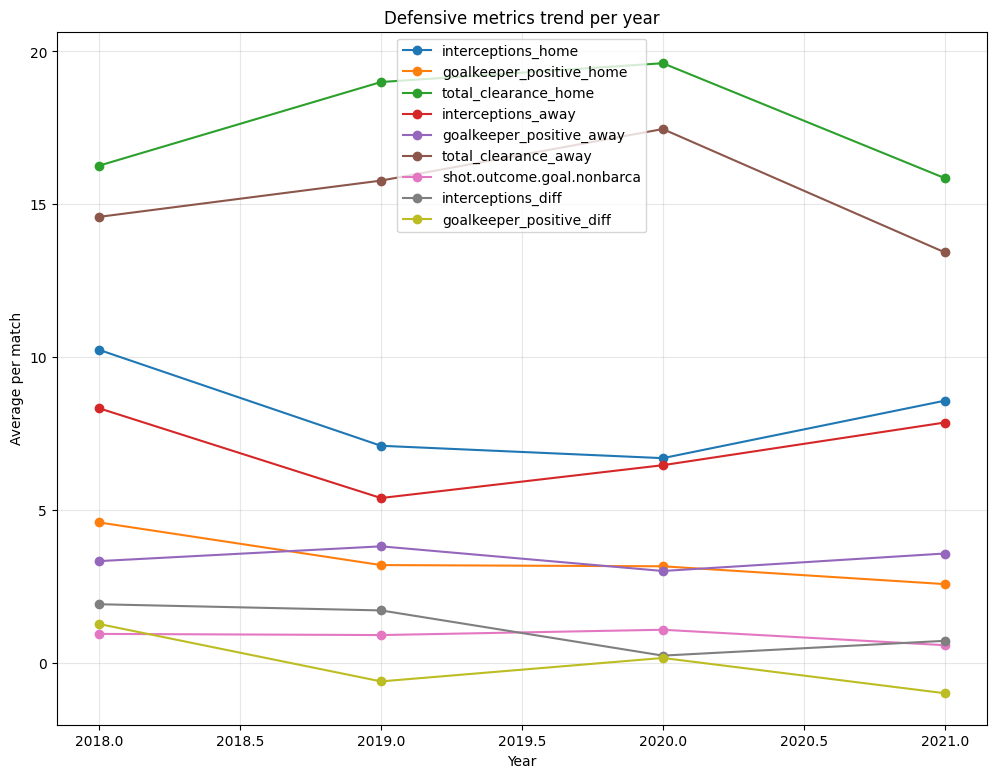

In [29]:
# Gunakan proxy defensive: duel counts, clearances, fouls
defensive_features = [c for c in df_merged.columns if any(k in c for k in ['duel','clearance','tackle','interception','conceded','nonbarca','goalkeeper'])]
print('Detected defensive-related columns:', defensive_features[:20])

if defensive_features:
    df_merged['match_date'] = pd.to_datetime(df_merged['match_date'])
    df_merged['year'] = df_merged['match_date'].dt.year
    def_summary = df_merged.groupby('year')[defensive_features].mean()
    print('\nAverage defensive metrics per year:')
    display(def_summary)

    # Plot trends for first few defensive metrics
    to_plot = defensive_features[:9]
    if to_plot:
        plt.figure(figsize=(12,9))
        for c in to_plot:
            if c in def_summary.columns:
                plt.plot(def_summary.index, def_summary[c], marker='o', label=c)
        plt.legend()
        plt.title('Defensive metrics trend per year')
        plt.xlabel('Year')
        plt.ylabel('Average per match')
        plt.grid(alpha=0.3)
        plt.show()
else:
    print('Tidak ditemukan kolom defensif yang jelas di df_merged. Pastikan aggregated defensive features dibuat saat agregasi events.')

Defensive columns detected: ['interceptions_home', 'goalkeeper_positive_home', 'total_clearance_home', 'interceptions_away', 'goalkeeper_positive_away', 'total_clearance_away', 'shot.outcome.goal.nonbarca', 'interceptions_diff', 'goalkeeper_positive_diff', 'total_clearance_diff']

Top opponents by matches (top 30):


opponent
Athletic Club             4
Granada                   4
Valencia                  4
Sevilla                   4
Real Valladolid           4
Real Sociedad             4
Real Madrid               4
Real Betis                4
Levante UD                4
Atlético Madrid           4
Leganés                   4
Getafe                    4
Espanyol                  4
Eibar                     4
Deportivo Alavés          4
Celta Vigo                4
Villarreal                4
Huesca                    3
Girona                    3
Osasuna                   3
Mallorca                  2
Cádiz                     2
Las Palmas                1
RC Deportivo La Coruña    1
Rayo Vallecano            1
Elche                     1
Name: (interceptions_home, count), dtype: int64


Defensive summary (mean) for top opponents:


,interceptions_home,goalkeeper_positive_home,total_clearance_home,interceptions_away,goalkeeper_positive_away,total_clearance_away,shot.outcome.goal.nonbarca,interceptions_diff,goalkeeper_positive_diff,total_clearance_diff
opponent,,,,,,,,,,
Getafe,14.750000,2.750000,16.25,5.500000,2.750000,15.25,0.500000,9.25,0.000000,1.000000
Elche,14.000000,1.000000,16.0,12.000000,4.000000,11.0,0.000000,2.00,-3.000000,5.000000
Athletic Club,12.750000,4.500000,23.0,7.500000,3.250000,19.5,0.250000,5.25,1.250000,3.500000
Deportivo Alavés,12.000000,3.500000,21.75,4.000000,4.250000,13.5,0.500000,8.00,-0.750000,8.250000
Girona,11.666667,4.333333,14.333333,6.666667,6.333333,11.0,0.666667,5.00,-2.000000,3.333333
RC Deportivo La Coruña,11.000000,4.000000,21.0,11.000000,5.000000,19.0,2.000000,0.00,-1.000000,2.000000
Cádiz,10.500000,6.000000,17.0,9.500000,3.500000,22.5,1.000000,1.00,2.500000,-5.500000
Eibar,10.000000,2.750000,30.0,8.750000,4.250000,14.0,0.500000,1.25,-1.500000,16.000000
Atlético Madrid,9.750000,4.250000,19.25,7.750000,2.250000,16.75,0.250000,2.00,2.000000,2.500000


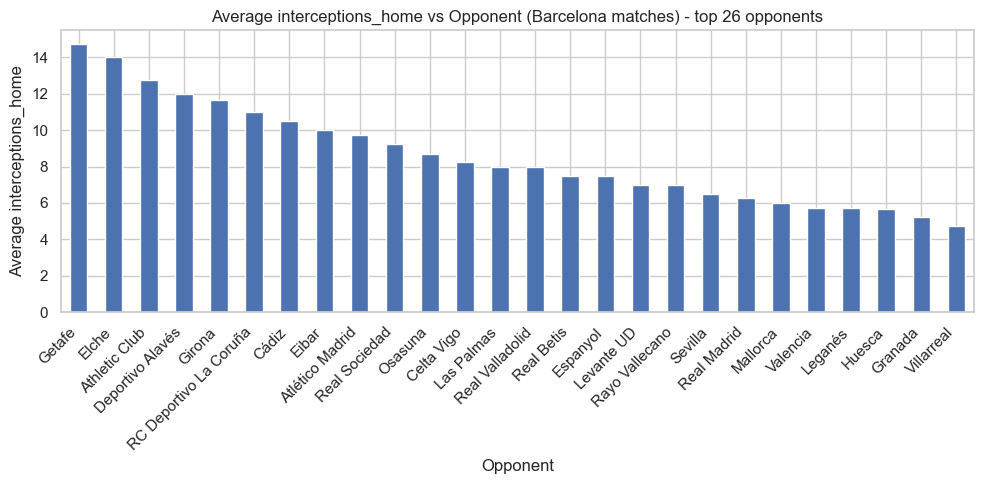

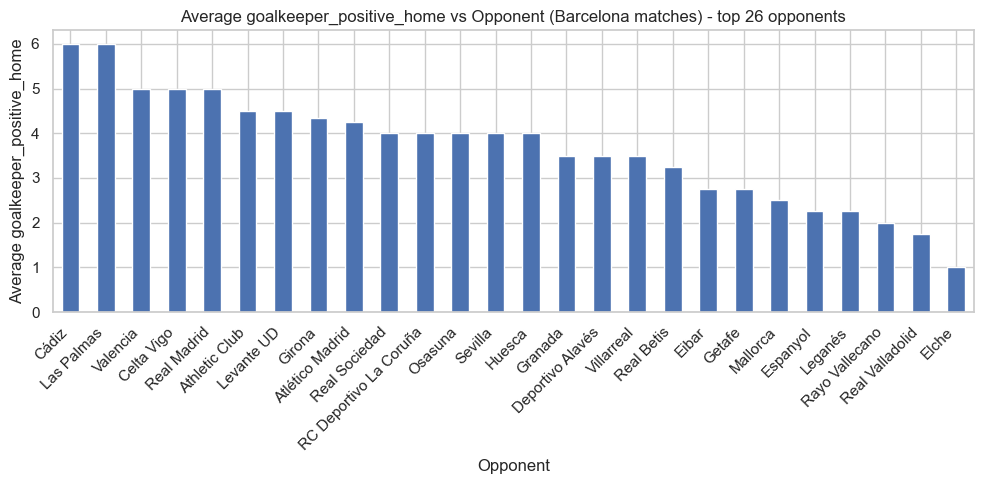

C:\Users\sayyi\AppData\Local\Temp\ipykernel_24900\3596176705.py:42: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  vals = df_barca.groupby('opponent')[metric].mean().loc[top_n].fillna(0)


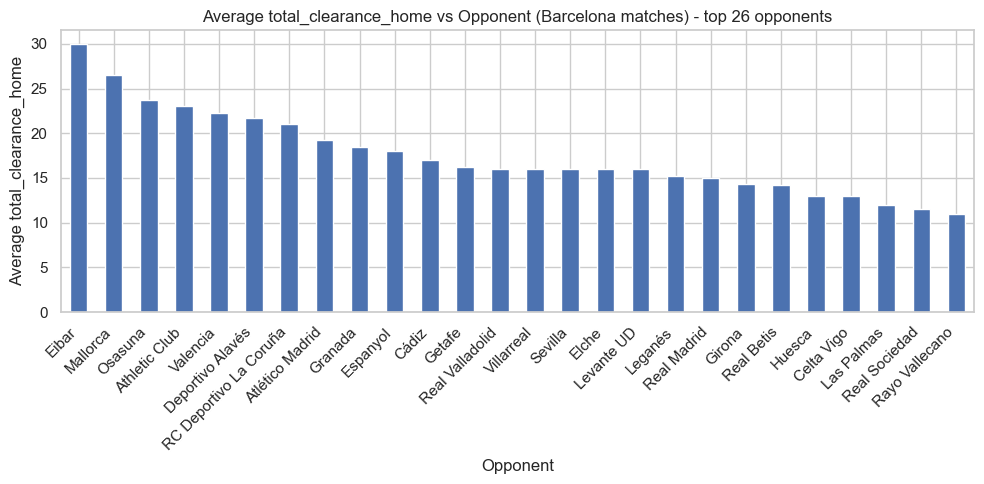

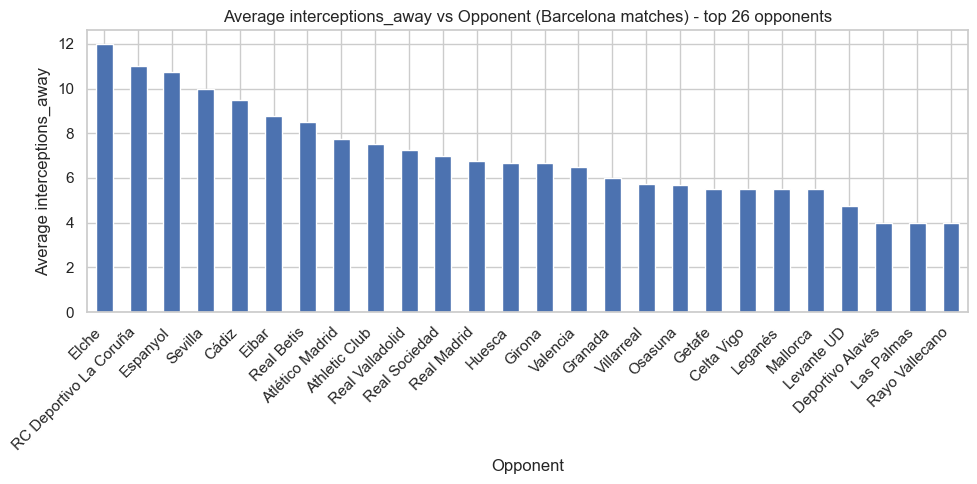

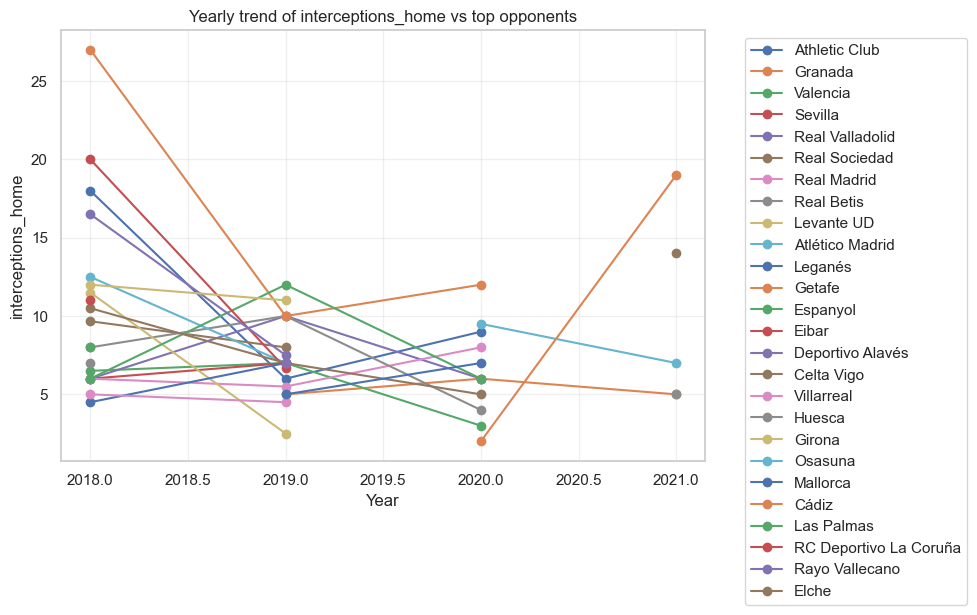

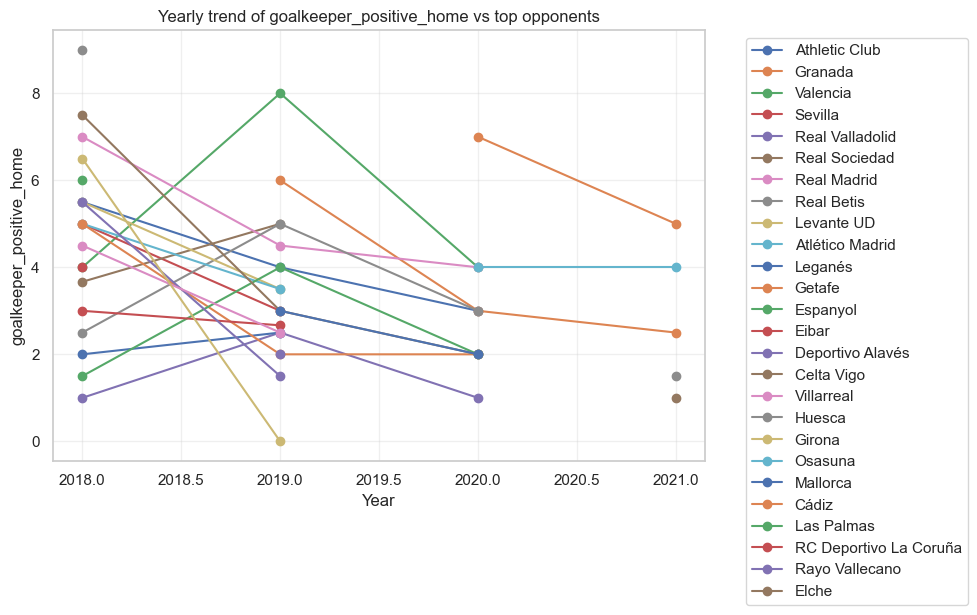

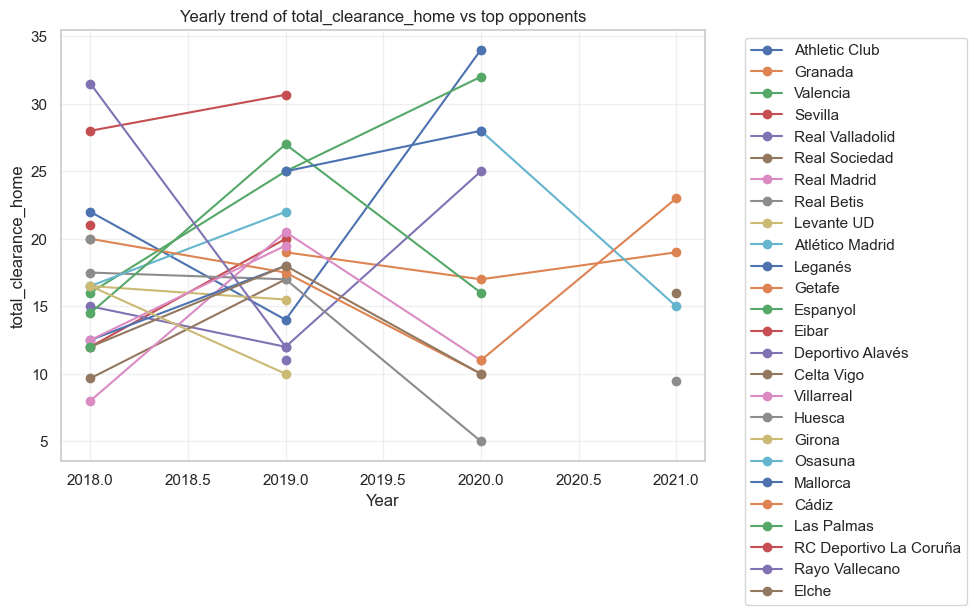

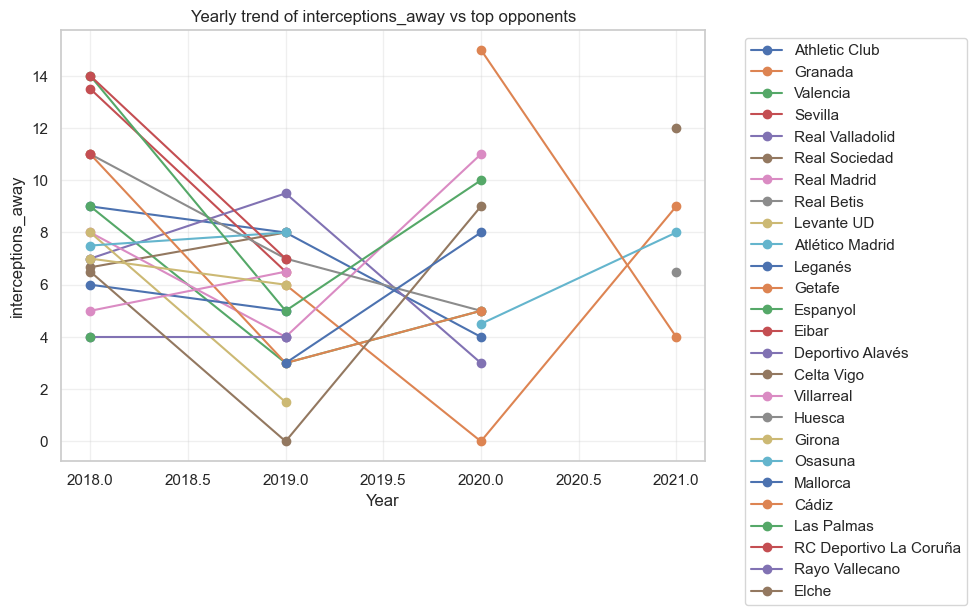

In [30]:

# 1) Fokus hanya pertandingan Barcelona
barca_mask = (
    df_merged['home_team.home_team_name'].astype(str).str.contains('barcelona', case=False, na=False) |
    df_merged['away_team.away_team_name'].astype(str).str.contains('barcelona', case=False, na=False)
)
df_barca = df_merged.loc[barca_mask].copy()
if df_barca.empty:
    print("Tidak ada match Barcelona ditemukan di df_merged.")
else:
    # 2) Tentukan lawan dan apakah Barca main kandang
    df_barca['barca_is_home'] = df_barca['home_team.home_team_name'].astype(str).str.contains('barcelona', case=False, na=False)
    df_barca['opponent'] = np.where(df_barca['barca_is_home'], df_barca['away_team.away_team_name'], df_barca['home_team.home_team_name'])
    df_barca['opponent'] = df_barca['opponent'].fillna('Unknown')

    # 3) Defensive columns (gunakan fitur agregat defensif yang sudah dibuat)
    defensive_cols = [c for c in df_barca.columns if any(k in c for k in ['duel','clearance','tackle','interception','conceded','nonbarca','goalkeeper'])]
    if not defensive_cols:
        print("Tidak ditemukan kolom defensif di df_merged. Pastikan agregasi defensif dibuat sebelumnya.")
    else:
        print("Defensive columns detected:", defensive_cols)

        # 4) Ringkasan per opponent
        opp_summary = df_barca.groupby('opponent')[defensive_cols].agg(['mean','std','count'])
        # tampilkan top opponent berdasarkan jumlah match
        opp_counts = opp_summary[ (defensive_cols[0],'count') ].sort_values(ascending=False)
        top_opponents = opp_counts.head(30).index.tolist()
        print("\nTop opponents by matches (top 30):")
        display(opp_counts.head(30))

        print("\nDefensive summary (mean) for top opponents:")
        display(opp_summary.loc[top_opponents].xs('mean', level=1, axis=1).sort_values(by=defensive_cols[0], ascending=False))

        # 5) Visualisasi: bar chart defensive metric per opponent (top N)
        import matplotlib.pyplot as plt
        import seaborn as sns
        sns.set(style="whitegrid")

        top_n = top_opponents[:30]
        metrics_to_plot = defensive_cols[:4]  # pilih beberapa metric defensif utama
        for metric in metrics_to_plot:
            plt.figure(figsize=(10,5))
            vals = df_barca.groupby('opponent')[metric].mean().loc[top_n].fillna(0)
            vals.sort_values(ascending=False).plot(kind='bar')
            plt.title(f"Average {metric} vs Opponent (Barcelona matches) - top {len(top_n)} opponents")
            plt.ylabel(f"Average {metric}")
            plt.xlabel("Opponent")
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()

        # 6) Trend per year untuk top opponents (lihat apakah ada adjustment)
        df_barca['match_date'] = pd.to_datetime(df_barca['match_date'], errors='coerce')
        df_barca['year'] = df_barca['match_date'].dt.year.fillna(0).astype(int)
        years = sorted(df_barca['year'].unique())

        for metric in metrics_to_plot:
            plt.figure(figsize=(10,6))
            for opp in top_n:
                series = df_barca[df_barca['opponent']==opp].groupby('year')[metric].mean().reindex(years)
                if series.notna().sum() > 0:
                    plt.plot(series.index, series.values, marker='o', label=opp)
            plt.title(f"Yearly trend of {metric} vs top opponents")
            plt.xlabel("Year")
            plt.ylabel(metric)
            plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()


#### 2. Tentukan gaya permainan tim mayoritas yang digunakan oleh Barcelona dari tahun ke tahun dari data yang ada. (Beberapa playstyle yang terkenal seperti: Possession Game, Quick Counter, Long Ball Counter, Out Wide, Long Ball; di luar ini, juga banyak, bisa dieksplorasi lebih lanjut)

In [31]:
playsyles = ['Possesion Game', 'Quick Counter', 'Long Ball Counter', 'Out Wide', 'Long Ball', 'High Press', 'Tiki Taka', 'Direct Play', 'Wing Play', 'Park the Bus']

cols_possession = [
    "match_id",
    "team.name",
    "player.name",
    "timestamp",
    "period",
    "possession",
    "duration",
    "type.name",
    "location",
    "pass.recipient.name",
    "pass.angle",
    "pass.height.name",
    "pass.type.name",
    "pass.outcome.name",
    "pass.cross",
    "pass.through_ball",
    "pass.switch",
    "pass.cut_back",
    "carry.end_location",
    "dribble.outcome.name",
    "under_pressure",
    "counterpress",
    "duel.outcome.name",
    "interception.outcome.name",
    "goalkeeper.type.name",
    "goalkeeper.outcome.name"
]

barca_events = events_data[events_data["team.name"].astype(str).str.contains("barcelona", case=False, na=False)][cols_possession].copy()

# hitung agregat per possession — pakai .astype(str).str.lower() untuk hindari mismatch casing / NaN
possession_stats = (
    barca_events.groupby("possession")
    .agg(
        team=("team.name", "first"),
        duration=("duration", "sum"),
        total_passes=("type.name", lambda x: x.astype(str).str.lower().eq("pass").sum()),
        complete_passes=("pass.outcome.name", lambda x: x.astype(str).str.lower().eq("complete").sum()),
        short_passes=("pass.height.name", lambda x: x.astype(str).str.lower().eq("ground pass").sum()),
        carries=("type.name", lambda x: x.astype(str).str.lower().eq("carry").sum()),
        dribbles=("type.name", lambda x: x.astype(str).str.lower().eq("dribble").sum()),
        duels_lost=("duel.outcome.name", lambda x: x.astype(str).str.lower().eq("lost").sum()),
        duels_won=("duel.outcome.name", lambda x: x.astype(str).str.lower().eq("won").sum())
    )
    .reset_index()
)

# hindari pembagian oleh 0
possession_stats["pass_accuracy"] = possession_stats["complete_passes"] / possession_stats["total_passes"].replace(0, np.nan)
possession_stats["pass_accuracy"] = possession_stats["pass_accuracy"].fillna(0.0)

possession_stats["short_pass_ratio"] = possession_stats["short_passes"] / possession_stats["total_passes"].replace(0, np.nan)
possession_stats["short_pass_ratio"] = possession_stats["short_pass_ratio"].fillna(0.0)

possession_stats["passes_per_possession"] = possession_stats["total_passes"] / possession_stats["duration"].replace(0, np.nan)
possession_stats["passes_per_possession"] = possession_stats["passes_per_possession"].fillna(0.0)

# ...existing code...
barca_summary = possession_stats.groupby("team").agg(
    avg_possession_duration=("duration", "mean"),
    avg_pass_accuracy=("pass_accuracy", "mean"),
    avg_short_pass_ratio=("short_pass_ratio", "mean"),
    avg_passes_per_possession=("passes_per_possession", "mean"),
    avg_duel_success_rate=("duels_won", lambda x: x.sum() / (x.sum() + possession_stats["duels_lost"].sum()) if (x.sum() + possession_stats["duels_lost"].sum())>0 else 0)
)

display(barca_summary.head())

,avg_possession_duration,avg_pass_accuracy,avg_short_pass_ratio,avg_passes_per_possession,avg_duel_success_rate
team,,,,,
Barcelona,801.317157,0.0,0.753055,0.326132,1.0


In [32]:
barca_matches = match_data[match_data["home_team.home_team_name"] == "Barcelona"]  # jika Barcelona home
match_data['match_date'] = pd.to_datetime(match_data['match_date'], errors='coerce')
if 'season' not in match_data.columns:
    match_data['season'] = match_data['match_date'].dt.year.astype('Int64')  # tahun sebagai season

# jika ingin filter match Barca (opsional)
barca_matches = match_data[match_data["home_team.home_team_name"].astype(str).str.contains("Barcelona", case=False, na=False)]

# merge barca_events dengan kolom season yang sekarang pasti ada
barca_events = barca_events.merge(match_data[['match_id', 'season']], on='match_id', how='left')

# Agregasi per musim/tahun
eda = (
    barca_events.groupby("season")
    .agg(
        passes=("type.name", lambda x: (x == "Pass").sum()),
        pass_complete=("pass.outcome.name", lambda x: (x == "Complete").sum()),
        pass_long=("pass.height.name", lambda x: (x == "High Pass").sum()),
        pass_short=("pass.height.name", lambda x: (x == "Ground Pass").sum()),
        carries=("type.name", lambda x: (x == "Carry").sum()),
        dribbles=("type.name", lambda x: (x == "Dribble").sum()),
        duels_won=("duel.outcome.name", lambda x: (x == "Won").sum()),
        duels_lost=("duel.outcome.name", lambda x: (x == "Lost").sum()),
        under_pressure=("under_pressure", lambda x: (x == True).sum()),
        counterpress=("counterpress", lambda x: (x == True).sum()),
        avg_duration=("duration", "mean")
    )
    .reset_index()
)

# Hitung metrik turunan
eda["pass_accuracy"] = eda["pass_complete"] / eda["passes"]
eda["short_pass_ratio"] = eda["pass_short"] / eda["passes"]
eda["long_pass_ratio"] = eda["pass_long"] / eda["passes"]
eda["duel_success_rate"] = eda["duels_won"] / (eda["duels_won"] + eda["duels_lost"])

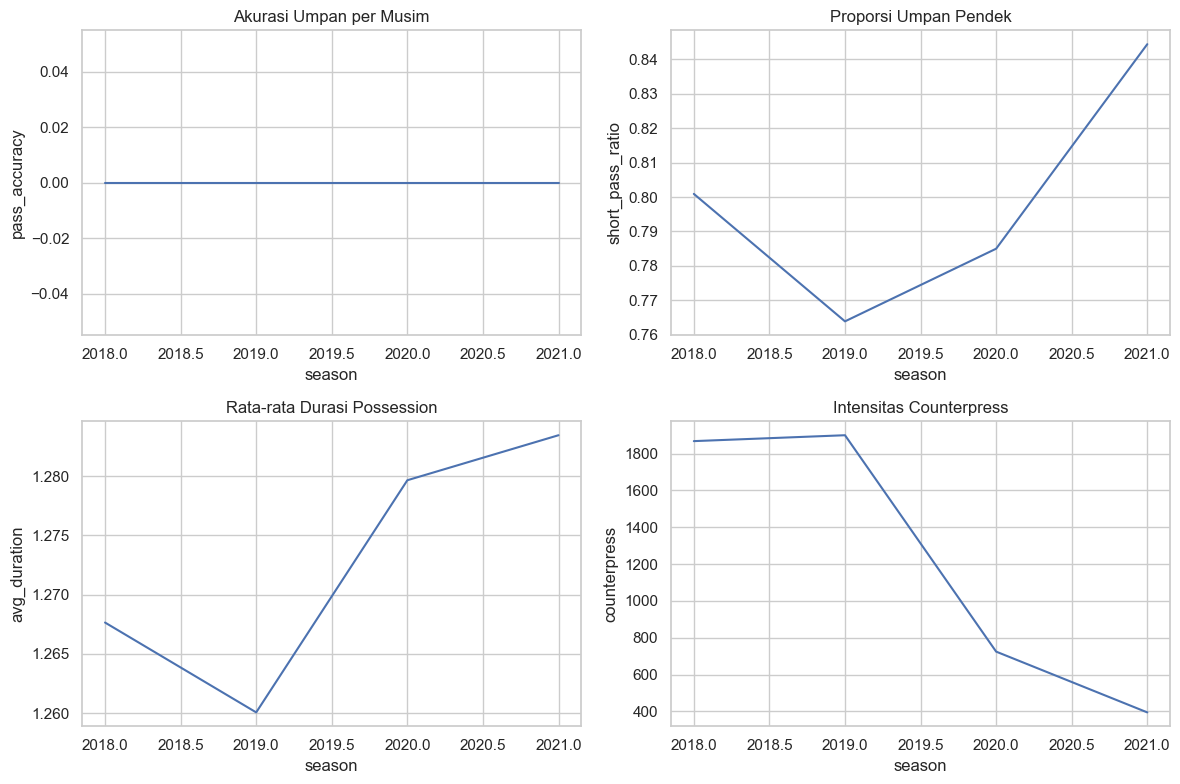

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.lineplot(data=eda, x="season", y="pass_accuracy", ax=axes[0,0]).set_title("Akurasi Umpan per Musim")
sns.lineplot(data=eda, x="season", y="short_pass_ratio", ax=axes[0,1]).set_title("Proporsi Umpan Pendek")
sns.lineplot(data=eda, x="season", y="avg_duration", ax=axes[1,0]).set_title("Rata-rata Durasi Possession")
sns.lineplot(data=eda, x="season", y="counterpress", ax=axes[1,1]).set_title("Intensitas Counterpress")

plt.tight_layout()
plt.show()

In [34]:
def classify_playstyle(row):
    if row["pass_accuracy"] > 0.87 and row["short_pass_ratio"] > 0.75:
        return "Tiki Taka"
    elif row["pass_accuracy"] > 0.85 and row["avg_duration"] > 10:
        return "Possession Game"
    elif row["long_pass_ratio"] > 0.25 and row["avg_duration"] < 8:
        return "Long Ball Counter"
    elif row["counterpress"] > eda["counterpress"].mean() * 1.2:
        return "High Press"
    elif row["short_pass_ratio"] < 0.5 and row["avg_duration"] < 6:
        return "Direct Play"
    else:
        return "Mixed Playstyle"

eda["playstyle"] = eda.apply(classify_playstyle, axis=1)
eda[["season", "playstyle"]]


,season,playstyle
0,2018,High Press
1,2019,High Press
2,2020,Mixed Playstyle
3,2021,Mixed Playstyle


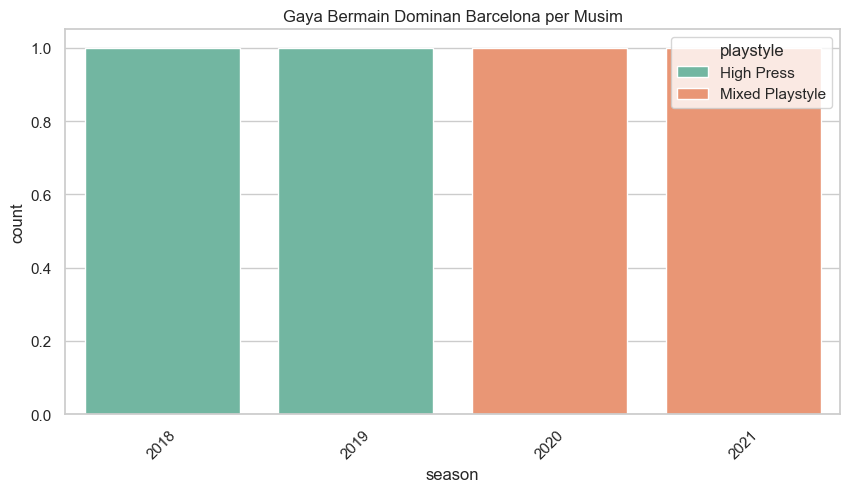

In [35]:
plt.figure(figsize=(10,5))
sns.countplot(data=eda, x="season", hue="playstyle", palette="Set2")
plt.title("Gaya Bermain Dominan Barcelona per Musim")
plt.xticks(rotation=45)
plt.show()


#### 3. Apakah suatu formasi tertentu cenderung meng-counter formasi tim tertentu? Hubungkan dengan berbagai hal, misalnya pergerakan ofensif dan pengerakan defensif tim.

In [36]:
# === Analisis formasi (jika ada kolom formation / play_pattern) ===
# Detect possible formation/play columns
formation_cols = [c for c in df_merged.columns if 'formation' in c.lower() or 'formation' in c]
play_pattern_cols = [c for c in df_merged.columns if 'play_pattern' in c.lower() or 'playstyle' in c.lower() or 'play_pattern.name' in c]

print('Detected formation columns:', formation_cols)
print('Detected play pattern columns:', play_pattern_cols)

if formation_cols:
    # Example: if home formation and away formation exist in match_data
    home_formation_col = None
    away_formation_col = None
    for c in formation_cols:
        if 'home' in c.lower():
            home_formation_col = c
        if 'away' in c.lower():
            away_formation_col = c
    # fallback: take first two if they exist
    if not home_formation_col and len(formation_cols) >= 1:
        home_formation_col = formation_cols[0]
    if not away_formation_col and len(formation_cols) >= 2:
        away_formation_col = formation_cols[1]

    if home_formation_col and away_formation_col:
        print(f'Using {home_formation_col} (home) and {away_formation_col} (away) to analyze formation matchups')
        ct = pd.crosstab(df_merged[home_formation_col], df_merged[away_formation_col])
        display(ct)
        plt.figure(figsize=(10,6))
        sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
        plt.title('Formation matchups: home vs away')
        plt.xlabel('Away formation')
        plt.ylabel('Home formation')
        plt.tight_layout()
        plt.show()
    else:
        print('Kolom formation tidak lengkap untuk analisis matchup (butuh home & away formation).')
else:
    print('Tidak ditemukan kolom formation di df_merged. Jika Anda punya data formation, tambahkan atau cek nama kolomnya.')

# If play_pattern columns exist, show distribution
if play_pattern_cols:
    for c in play_pattern_cols:
        print('\nDistribution of', c)
        display(df_merged[c].value_counts().head(20))
else:
    print('Tidak ditemukan kolom play_pattern / playstyle eksplisit di df_merged. play_pattern biasanya di events_data (kolom play_pattern.name) jika tersedia.')

Detected formation columns: []
Detected play pattern columns: []
Tidak ditemukan kolom formation di df_merged. Jika Anda punya data formation, tambahkan atau cek nama kolomnya.
Tidak ditemukan kolom play_pattern / playstyle eksplisit di df_merged. play_pattern biasanya di events_data (kolom play_pattern.name) jika tersedia.


#### 4. Siapakah pemain Barcelona yang kerap menjadi pemecah kebuntuan tim (ketika hasil masih defisit atau seri bagi tim yang bersangkutan) dalam dataset ini?

Terdapat 274 goal-event yang terdeteksi (berdasarkan kolom shot.outcome.name).


,player.name,shot.outcome.name,possession_team.name,match_id
775,Arturo Erasmo Vidal Pardo,Goal,Barcelona,303680
5438,Luis Alberto Suárez Díaz,Goal,Barcelona,16095
5660,Lionel Andrés Messi Cuccittini,Goal,Barcelona,16095
5803,Lionel Andrés Messi Cuccittini,Goal,Barcelona,16095
6271,Lionel Andrés Messi Cuccittini,Goal,Barcelona,16095



Top pemain yang menjadi pemecah kebuntuan (hanya Barcelona):


Lionel Andrés Messi Cuccittini    39
Luis Alberto Suárez Díaz          19
Ousmane Dembélé                    7
Arturo Erasmo Vidal Pardo          7
Philippe Coutinho Correia          6
Antoine Griezmann                  6
Gerard Piqué Bernabéu              4
Ivan Rakitić                       3
Clément Lenglet                    3
Francisco Alcácer García           2
dtype: int64

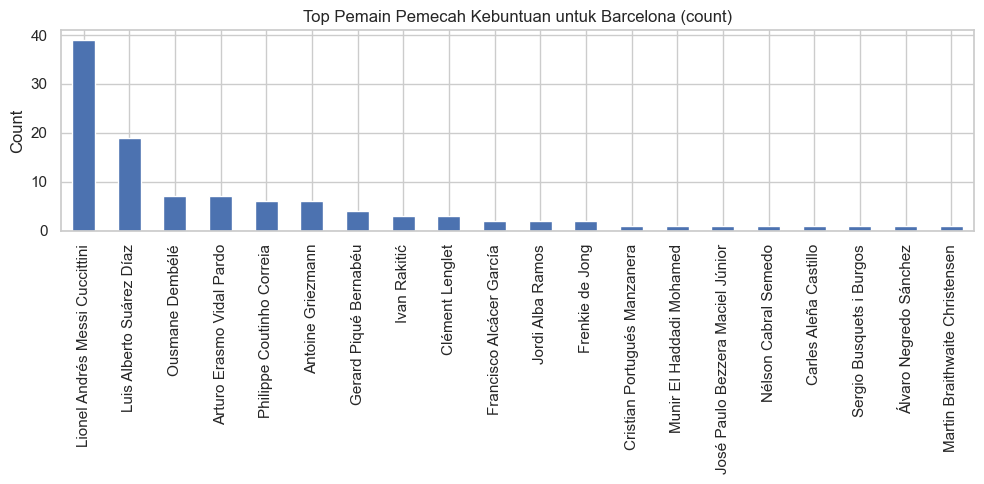

In [37]:
# Flexible detection of goal events & team column
team_col = None
for candidate in ['possession_team.name', 'team.name', 'team', 'possession_team']:
    if candidate in events_data.columns:
        team_col = candidate
        break

goal_col = None
if 'shot.outcome.name' in events_data.columns:
    goal_col = 'shot.outcome.name'
elif 'type.name' in events_data.columns:
    goal_col = 'type.name'

if team_col is None or goal_col is None or 'player.name' not in events_data.columns:
    print('Kolom yang dibutuhkan tidak lengkap di events_data. Diperlukan kolom: player.name, team identifier (possession_team.name atau team.name), dan kolom yang menandai goal (shot.outcome.name atau type.name).')
else:
    ev = events_data.copy().reset_index()
    ev['is_goal'] = ev[goal_col].astype(str).str.contains('goal', case=False, na=False)
    goals = ev[ev['is_goal']].copy()
    print(f'Terdapat {len(goals)} goal-event yang terdeteksi (berdasarkan kolom {goal_col}).')

    #display player.name,shot.outcome.name,team_col,match_id
    display(goals[['player.name', goal_col, team_col, 'match_id']].head(5))
    
    # Build timeline per match
    from collections import defaultdict
    scorer_counts = defaultdict(int)
    match_summaries = []

    for mid, gdf in goals.groupby('match_id'):
        gdf = gdf.sort_values('index')  # asumsi urutan kronologis sesuai index
        # Determine home/away team names from match_data
        row = match_data[match_data['match_id'] == mid]
        if row.empty:
            continue
        home = row.iloc[0].get('home_team.home_team_name', None)
        away = row.iloc[0].get('away_team.away_team_name', None)

        # track scores
        score = {home:0, away:0}
        # iterate goal events
        for _, evrow in gdf.iterrows():
            team = evrow[team_col]
            player = evrow.get('player.name', None)
            if pd.isna(team) or pd.isna(player):
                continue
            # before the goal
            opp = home if team == away else away
            team_before = score.get(team, 0)
            opp_before = score.get(opp, 0)
            # condition: previously trailing or tied
            if team_before <= opp_before:
                # count if this team is Barcelona (either home or away)
                if (str(team).lower() == 'barcelona') or (home == 'Barcelona' and team==home) or (away == 'Barcelona' and team==away):
                    scorer_counts[player] += 1
            # update score (assume goal increments by 1)
            score[team] = team_before + 1

    # Show top players
    scorer_series = pd.Series(scorer_counts).sort_values(ascending=False)
    print('\nTop pemain yang menjadi pemecah kebuntuan (hanya Barcelona):')
    if scorer_series.empty:
        print('Tidak ditemukan goal-event yang memenuhi kondisi atau kolom team names tidak konsisten.')
    else:
        display(scorer_series.head(10))
        scorer_series.head(20).plot(kind='bar', figsize=(10,5))
        plt.title('Top Pemain Pemecah Kebuntuan untuk Barcelona (count)')
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()

berdasarkan analisis EDA poin 4 di atas, dapat disimpulkan bahwa pemain Barcelona yang kerap menjadi pemecah kebuntuan tim dalam dataset ini adalah **Lionel Messi** dengan total 39 events (goal contribution events) yang berkontribusi pada perubahan skor ketika tim dalam kondisi defisit atau seri. Disusul oleh **Luis Suárez** dengan 19 events, dan **Arturo Vidal.** dengan 7 events.

#### 5. Apakah possession yang lebih tinggi berkorelasi dengan xG / shots on target / peluang bersih? 

xG model CV AUC (5-fold): [0.908 0.92  0.907 0.922 0.896]


,match_id,team.name,possession_mean,shots,shots_on_target,xG_sum,big_chances,possession_pct
0,9742,Barcelona,88.397590,47,21,20.810886,21,88.397590
1,9742,Levante UD,93.676744,39,2,23.593096,2,93.676744
2,9754,Barcelona,88.599789,65,41,31.819933,41,88.599789
3,9754,Real Sociedad,95.540383,47,27,27.972009,27,95.540383
4,9765,Barcelona,89.693659,83,55,53.935543,55,89.693659
5,9765,Real Betis,92.368201,32,3,10.170673,3,92.368201
6,9774,Barcelona,101.552245,55,30,28.610364,30,101.552245
7,9774,Deportivo Alavés,108.814885,24,8,14.666324,8,108.814885
8,9783,Barcelona,87.102423,62,9,33.247842,9,87.102423
9,9783,Espanyol,96.362039,20,7,10.115079,7,96.362039


,metric,n,pearson_r,pearson_p,spearman_r,spearman_p
0,shots,170,-0.009506,0.902080,0.030373,0.694182
1,shots_on_target,170,-0.131198,0.088126,-0.111467,0.147856
2,xG_sum,170,-0.098750,0.200134,-0.061049,0.429035
3,big_chances,170,-0.131198,0.088126,-0.111467,0.147856


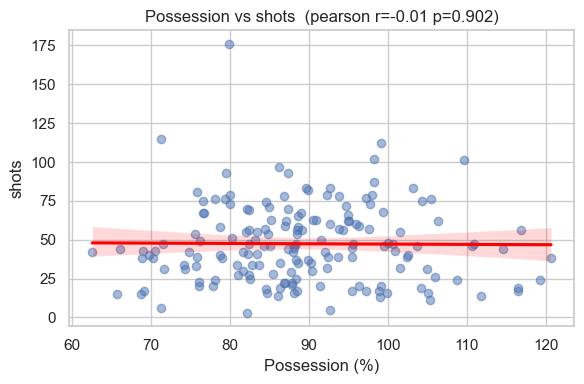

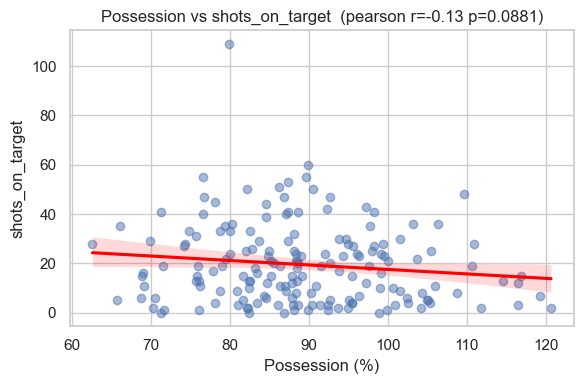

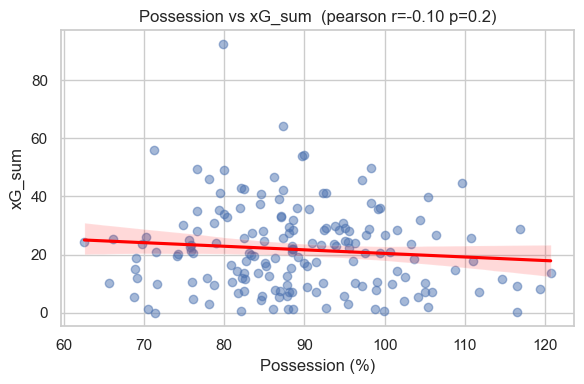

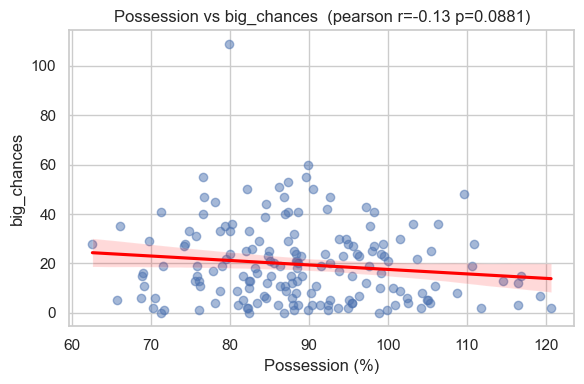

Ringkasan interpretasi (rule-of-thumb):
- shots: n=170, pearson r=-0.010, p=0.902 -> sangat lemah / hampir tidak ada korelasi
- shots_on_target: n=170, pearson r=-0.131, p=0.0881 -> lemah
- xG_sum: n=170, pearson r=-0.099, p=0.2 -> sangat lemah / hampir tidak ada korelasi
- big_chances: n=170, pearson r=-0.131, p=0.0881 -> lemah


In [38]:
# NEW CELL: Integrasi pipeline untuk menjawab: apakah possession berkorelasi dengan xG / shots on target / peluang bersih?
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from scipy import stats

sns.set(style="whitegrid")

# use existing dataframes
ev = events_data.copy()
md = match_data.copy()

# detect team col and possession col in events (fallbacks)
team_col = next((c for c in ['team.name','possession_team.name','team'] if c in ev.columns), None)
pos_col = next((c for c in ['possession','possession_pct','possession_pct_home','possession_home'] if c in ev.columns), None)

# detect shot type/outcome cols and candidate xg/big chance cols
shot_type_col = next((c for c in ['type.name','event.type'] if c in ev.columns), None)
shot_outcome_col = next((c for c in ['shot.outcome.name','shot.outcome'] if c in ev.columns), None)
xg_col = next((c for c in ev.columns if 'xg' in c.lower()), None)
big_chance_col = next((c for c in ev.columns if 'big' in c.lower() or 'big_chance' in c.lower() or 'clear_chance' in c.lower()), None)

if team_col is None:
    raise RuntimeError("Team column not found in events_data; needed for per-team aggregation.")

def extract_xy(val):
    try:
        if isinstance(val, (list, tuple)):
            return float(val[0]), float(val[1])
        s = str(val).strip().strip('[]() ')
        parts = [p.strip() for p in s.split(',') if p.strip()!='']
        if len(parts) >= 2:
            return float(parts[0]), float(parts[1])
    except:
        pass
    return (np.nan, np.nan)

# ensure loc_x/loc_y present
if 'loc_x' not in ev.columns or 'loc_y' not in ev.columns:
    if 'shot.end_location' in ev.columns:
        ev[['loc_x','loc_y']] = ev['shot.end_location'].apply(lambda v: pd.Series(extract_xy(v)))
    elif 'location' in ev.columns:
        ev[['loc_x','loc_y']] = ev['location'].apply(lambda v: pd.Series(extract_xy(v)))
    elif 'location_x' in ev.columns and 'location_y' in ev.columns:
        ev['loc_x'] = pd.to_numeric(ev['location_x'], errors='coerce')
        ev['loc_y'] = pd.to_numeric(ev['location_y'], errors='coerce')

# detect shot rows robustly
def is_shot_row(r):
    if shot_type_col and isinstance(r.get(shot_type_col), str) and 'shot' in r.get(shot_type_col).lower():
        return True
    if shot_outcome_col and isinstance(r.get(shot_outcome_col), str):
        if any(k in r.get(shot_outcome_col).lower() for k in ('shot','goal','on target','saved')):
            return True
    return False

ev['_is_shot'] = ev.apply(is_shot_row, axis=1)
shots = ev[ev['_is_shot']].copy()
shots = shots.dropna(subset=['loc_x','loc_y'], how='any').copy()

if not shots.empty and xg_col is None:
    # compute simple distance & angle features
    x_min, x_max = shots['loc_x'].min(), shots['loc_x'].max()
    y_min, y_max = shots['loc_y'].min(), shots['loc_y'].max()
    y_center = (y_min + y_max) / 2.0
    # estimate goal half-width in data units
    goal_half = (y_max - y_min) * (7.32 / 68.0) / 2.0
    left_goal_x, right_goal_x = x_min, x_max

    def shot_feats(r):
        x, y = r['loc_x'], r['loc_y']
        gx = left_goal_x if abs(x-left_goal_x) < abs(x-right_goal_x) else right_goal_x
        gyc = y_center
        dx = gx - x
        dy = gyc - y
        distance = math.hypot(dx, dy)
        top_post = (gx, gyc + goal_half)
        bot_post = (gx, gyc - goal_half)
        a1 = math.atan2(top_post[1] - y, top_post[0] - x)
        a2 = math.atan2(bot_post[1] - y, bot_post[0] - x)
        angle = abs(a1 - a2)
        is_header = 0
        for b in ['shot.body_part','shot.body_part.name','body_part.name','body_part']:
            if b in r and pd.notna(r[b]) and isinstance(r[b], str) and 'head' in r[b].lower():
                is_header = 1
                break
        under_pressure = int(r['under_pressure']) if 'under_pressure' in r and pd.notna(r['under_pressure']) else 0
        counterpress = int(r['counterpress']) if 'counterpress' in r and pd.notna(r['counterpress']) else 0
        return pd.Series([distance, angle, is_header, under_pressure, counterpress],
                         index=['distance','angle','is_header','under_pressure','counterpress'])
    feat_df = shots.apply(shot_feats, axis=1)
    shots = pd.concat([shots.reset_index(drop=True), feat_df.reset_index(drop=True)], axis=1)

    # label is_goal
    if 'shot.outcome.goal' in shots.columns:
        shots['is_goal'] = shots['shot.outcome.goal'].fillna(0).astype(int)
    elif shot_outcome_col:
        shots['is_goal'] = shots[shot_outcome_col].astype(str).str.contains('goal', case=False, na=False).astype(int)
    else:
        shots['is_goal'] = 0

    features = ['distance','angle','is_header','under_pressure','counterpress']
    X = shots[features].fillna(0).values
    y = shots['is_goal'].values

    if y.sum() >= 5 and len(y) >= 30:
        scaler = StandardScaler()
        Xs = scaler.fit_transform(X)
        clf = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
        try:
            scores = cross_val_score(clf, Xs, y, cv=5, scoring='roc_auc')
            print("xG model CV AUC (5-fold):", np.round(scores,3))
        except Exception:
            pass
        clf.fit(Xs, y)
        shots['xG'] = clf.predict_proba(Xs)[:,1]
        # merge back xG into ev (align by index if possible)
        ev = ev.merge(shots[['loc_x','loc_y','xG']], how='left', left_on=['loc_x','loc_y'], right_on=['loc_x','loc_y'])
        # if merge created duplicates, prefer shots.xG
        if 'xG' not in ev.columns:
            ev['xG'] = np.nan
    else:
        print("Tidak cukup data untuk melatih xG model => xG akan bernilai NaN.")
        shots['xG'] = np.nan
        ev['xG'] = np.nan
else:
    # xg already present or no shots
    if xg_col:
        ev['xG'] = ev[xg_col]
    else:
        ev['xG'] = np.nan

# --- 2) Aggregate per match_id + team ---
# create shot on target proxy
def is_on_target(v):
    if pd.isna(v): return 0
    s = str(v).lower()
    return int(('on target' in s) or ('goal' in s) or ('saved' in s))
if shot_outcome_col:
    ev['_shot_on_target'] = ev[shot_outcome_col].apply(is_on_target)
else:
    ev['_shot_on_target'] = 0
# if big chance col exists, use as peluang_bersih proxy
if big_chance_col:
    ev['_big_chance'] = ev[big_chance_col].fillna(0).astype(int)
else:
    ev['_big_chance'] = ev['_shot_on_target']  # fallback

group_cols = ['match_id', team_col]
agg = ev.groupby(group_cols).agg(
    possession_mean = (pos_col, 'mean') if pos_col in ev.columns else ('duration','sum'),
    shots = ('_is_shot','sum'),
    shots_on_target = ('_shot_on_target','sum'),
    xG_sum = ('xG','sum'),
    big_chances = ('_big_chance','sum')
).reset_index()

# normalize possession if >1 (some datasets store 0-1)
if agg['possession_mean'].notna().any():
    if agg['possession_mean'].max() <= 1.01:
        agg['possession_pct'] = agg['possession_mean'] * 100
    else:
        agg['possession_pct'] = agg['possession_mean']

# clean NaNs
agg[['shots','shots_on_target','big_chances']] = agg[['shots','shots_on_target','big_chances']].fillna(0)
agg['xG_sum'] = agg['xG_sum'].fillna(0)

display(agg.head(10))

# --- 3) Correlations (possession_pct vs metrics) ---
metrics = ['shots','shots_on_target','xG_sum','big_chances']
rows = []
for m in metrics:
    x = agg['possession_pct'].values
    y = agg[m].values
    mask = (~np.isnan(x)) & (~np.isnan(y))
    n = int(mask.sum())
    if n >= 3:
        pr, pp = stats.pearsonr(x[mask], y[mask])
        sr = stats.spearmanr(x[mask], y[mask])
        rows.append({'metric':m, 'n':n, 'pearson_r':pr, 'pearson_p':pp,
                     'spearman_r': sr.correlation, 'spearman_p': sr.pvalue})
    else:
        rows.append({'metric':m, 'n':n, 'pearson_r':np.nan, 'pearson_p':np.nan,
                     'spearman_r':np.nan, 'spearman_p':np.nan})
corr_table = pd.DataFrame(rows)[['metric','n','pearson_r','pearson_p','spearman_r','spearman_p']]
display(corr_table)

# --- 4) plots & interpretation ---
def interpret_r(r):
    if np.isnan(r): return "tidak cukup data"
    ar = abs(r)
    if ar < 0.1: return "sangat lemah / hampir tidak ada korelasi"
    if ar < 0.3: return "lemah"
    if ar < 0.5: return "sedang"
    return "kuat"

for m in metrics:
    plt.figure(figsize=(6,4))
    sns.regplot(data=agg, x='possession_pct', y=m, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    row = corr_table[corr_table['metric']==m].iloc[0]
    r = row['pearson_r'] if not np.isnan(row['pearson_r']) else 0.0
    p = row['pearson_p'] if not np.isnan(row['pearson_p']) else np.nan
    plt.title(f'Possession vs {m}  (pearson r={r:.2f} p={p:.3g})')
    plt.xlabel('Possession (%)')
    plt.ylabel(m)
    plt.tight_layout()
    plt.show()

print("Ringkasan interpretasi (rule-of-thumb):")
for _, row in corr_table.iterrows():
    print(f"- {row['metric']}: n={int(row['n'])}, pearson r={row['pearson_r']:.3f}, p={row['pearson_p']:.3g} -> {interpret_r(row['pearson_r'])}")

#### 6. Siapa pemain yang paling sering menjadi "creator" sebelum shot (pass langsung sebelum shot)?

,passer,creations,creations_goal,teams,goal_rate
145,Lionel Andrés Messi Cuccittini,180,31,Barcelona,0.172222
189,Ousmane Dembélé,75,9,Barcelona,0.120000
150,Luis Alberto Suárez Díaz,74,12,Barcelona,0.162162
123,Jordi Alba Ramos,68,10,Barcelona,0.147059
201,Philippe Coutinho Correia,49,6,Barcelona,0.122449
236,Sergio Busquets i Burgos,31,1,Barcelona,0.032258
25,Arturo Erasmo Vidal Pardo,25,6,Barcelona,0.240000
104,Ivan Rakitić,25,5,Barcelona,0.200000
234,Sergi Roberto Carnicer,25,3,Barcelona,0.120000
22,Antoine Griezmann,24,5,Barcelona,0.208333


C:\Users\sayyi\AppData\Local\Temp\ipykernel_24900\466938523.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agg.head(topn), x='creations', y='passer', palette='viridis')


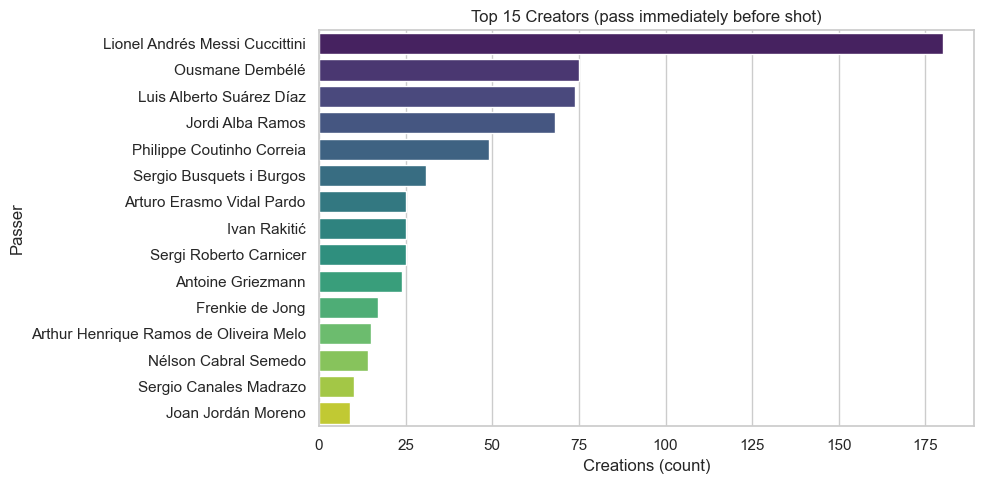

,passer,creations,goals,goal_rate
20,Lionel Andrés Messi Cuccittini,180,31,0.172222
29,Ousmane Dembélé,75,9,0.120000
22,Luis Alberto Suárez Díaz,74,12,0.162162
18,Jordi Alba Ramos,68,10,0.147059
31,Philippe Coutinho Correia,49,6,0.122449
36,Sergio Busquets i Burgos,31,1,0.032258
17,Ivan Rakitić,25,5,0.200000
7,Arturo Erasmo Vidal Pardo,25,6,0.240000
34,Sergi Roberto Carnicer,25,3,0.120000
5,Antoine Griezmann,22,4,0.181818


C:\Users\sayyi\AppData\Local\Temp\ipykernel_24900\466938523.py:138: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agg_barca.head(12), x='creations', y='passer', palette='rocket')


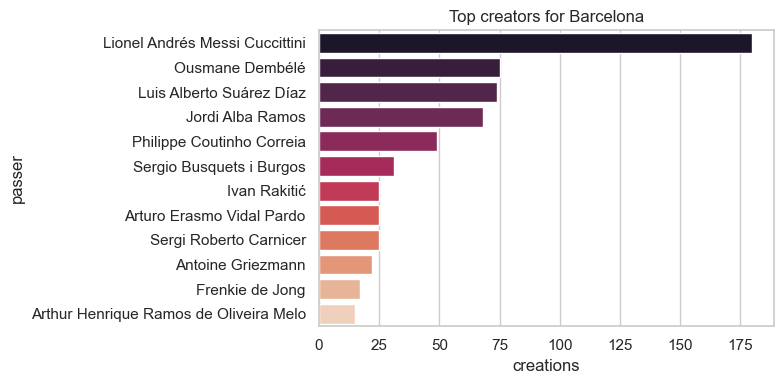

,season,passer,ct
86,2018,Lionel Andrés Messi Cuccittini,80
113,2018,Ousmane Dembélé,47
90,2018,Luis Alberto Suárez Díaz,40
71,2018,Jordi Alba Ramos,36
118,2018,Philippe Coutinho Correia,36
223,2019,Lionel Andrés Messi Cuccittini,59
226,2019,Luis Alberto Suárez Díaz,32
240,2019,Ousmane Dembélé,18
168,2019,Arturo Erasmo Vidal Pardo,14
213,2019,Jordi Alba Ramos,14


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# safe copies
ev = events_data.copy() if 'events_data' in globals() else None
md = match_data.copy() if 'match_data' in globals() else None

if ev is None or md is None:
    print("events_data atau match_data tidak tersedia — jalankan sel load dataset terlebih dahulu.")
else:
    # Normalize index / ordering (assume dataframe order is chronological if no timestamp)
    ev = ev.reset_index(drop=False).rename(columns={'index': 'orig_index'})
    ev = ev.sort_values(['match_id','orig_index']).reset_index(drop=True)

    # Detect columns
    team_col = next((c for c in ['team.name','possession_team.name','team'] if c in ev.columns), None)
    player_col = next((c for c in ['player.name','player'] if c in ev.columns), None)
    type_col = next((c for c in ['type.name','event.type','type'] if c in ev.columns), None)
    shot_outcome_col = next((c for c in ['shot.outcome.name','shot.outcome','type.name'] if c in ev.columns), None)
    pass_shot_assist_col = next((c for c in ['pass.shot_assist','pass.shot_assist.name','pass.shot_assist_flag'] if c in ev.columns), None)

    def is_shot_row(r):
        # robust shot detection
        if type_col and isinstance(r.get(type_col), str) and 'shot' in r.get(type_col).lower():
            return True
        if shot_outcome_col and isinstance(r.get(shot_outcome_col), str) and any(k in r.get(shot_outcome_col).lower() for k in ('goal','on target','saved','shot')):
            return True
        return False

    def is_pass_row(r):
        if type_col and isinstance(r.get(type_col), str) and 'pass' in r.get(type_col).lower():
            return True
        # fallback: presence of pass.recipient.name or pass.outcome.name
        if 'pass.recipient.name' in ev.columns and pd.notna(r.get('pass.recipient.name')):
            return True
        if 'pass.outcome.name' in ev.columns and pd.notna(r.get('pass.outcome.name')):
            return True
        return False

    ev['_is_shot'] = ev.apply(is_shot_row, axis=1)
    ev['_is_pass'] = ev.apply(is_pass_row, axis=1)

    # Look-back N events to find passer before each shot (same match, prefer same team)
    N_LOOKBACK = 3
    creators_rows = []
    for match_id, g in ev.groupby('match_id', sort=False):
        g = g.reset_index(drop=True)
        for i, row in g[g['_is_shot']].iterrows():
            shooter = row.get(player_col, None)
            shooter_team = row.get(team_col, None)
            shot_idx = row.name
            shot_goal = 0
            if shot_outcome_col and pd.notna(row.get(shot_outcome_col)):
                try:
                    shot_goal = int(str(row.get(shot_outcome_col)).lower().count('goal')>0)
                except:
                    shot_goal = 0
            # search back up to N_LOOKBACK (only within same match order)
            passer = None
            passer_team = None
            pass_type = None
            pass_shot_assist = 0
            for j in range(max(0, i - N_LOOKBACK), i)[::-1]:
                prev = g.iloc[j]
                if prev['_is_pass']:
                    # require same team for creator
                    if pd.notna(prev.get(team_col)) and pd.notna(shooter_team) and str(prev.get(team_col)).strip().lower() == str(shooter_team).strip().lower():
                        passer = prev.get(player_col, None)
                        passer_team = prev.get(team_col, None)
                        # pass type fields if available
                        for c in ['pass.type.name','pass.height.name','pass.body_part.name','pass.recipient.name']:
                            if c in prev.index and pd.notna(prev.get(c)):
                                pass_type = prev.get(c)
                                break
                        if pass_shot_assist_col and pass_shot_assist_col in prev.index:
                            try:
                                pass_shot_assist = int(bool(prev.get(pass_shot_assist_col)))
                            except:
                                pass_shot_assist = 0
                        break
            creators_rows.append({
                'match_id': match_id,
                'shot_index': row['orig_index'],
                'shooter': shooter,
                'shooter_team': shooter_team,
                'passer': passer,
                'passer_team': passer_team,
                'pass_type': pass_type,
                'pass_shot_assist': pass_shot_assist,
                'is_goal': shot_goal
            })

    creators_df = pd.DataFrame(creators_rows)
    # drop shots without identified passer
    creators_with_pass = creators_df[creators_df['passer'].notna()].copy()

    if creators_with_pass.empty:
        print("Tidak ditemukan pass langsung sebelum shot (per konfigurasi). Cek nama kolom atau naikkan N_LOOKBACK.")
    else:
        # Aggregate overall creators
        agg = creators_with_pass.groupby('passer').agg(
            creations=('passer', 'count'),
            creations_goal=('is_goal', 'sum'),
            teams=('passer_team', lambda x: x.mode().iloc[0] if len(x.mode())>0 else np.nan)
        ).reset_index().sort_values('creations', ascending=False)

        # Add conversion and xG per creation
        agg['goal_rate'] = agg['creations_goal'] / agg['creations']

        display(agg.head(30))

        # Top creators plot
        topn = 15
        plt.figure(figsize=(10,5))
        sns.barplot(data=agg.head(topn), x='creations', y='passer', palette='viridis')
        plt.title(f'Top {topn} Creators (pass immediately before shot)')
        plt.xlabel('Creations (count)')
        plt.ylabel('Passer')
        plt.tight_layout()
        plt.show()

        # Barcelona-specific creators (if team names present)
        if creators_with_pass['passer_team'].notna().any():
            is_barca = creators_with_pass['passer_team'].astype(str).str.contains('barcelona', case=False, na=False)
            barca_creators = creators_with_pass[is_barca].copy()
            if not barca_creators.empty:
                agg_barca = barca_creators.groupby('passer').agg(
                    creations=('passer','count'),
                    goals=('is_goal','sum'),
                ).reset_index().sort_values('creations', ascending=False)
                agg_barca['goal_rate'] = agg_barca['goals'] / agg_barca['creations']
                display(agg_barca.head(20))
                plt.figure(figsize=(8,4))
                sns.barplot(data=agg_barca.head(12), x='creations', y='passer', palette='rocket')
                plt.title('Top creators for Barcelona')
                plt.tight_layout()
                plt.show()
            else:
                print("Tidak ada creators dengan passer_team mengandung 'barcelona'.")

        # Per-season (optional) — merge match -> season if match_date/season exists
        if 'match_date' in md.columns or 'season' in md.columns:
            md2 = md[['match_id'] + (['season'] if 'season' in md.columns else []) + (['match_date'] if 'match_date' in md.columns else [])].copy()
            if 'match_date' in md2.columns and 'season' not in md2.columns:
                md2['match_date'] = pd.to_datetime(md2['match_date'], errors='coerce')
                md2['season'] = md2['match_date'].dt.year
            creators_season = creators_with_pass.merge(md2[['match_id','season']], on='match_id', how='left')
            season_table = creators_season.groupby(['season','passer']).agg(ct=('passer','count')).reset_index()
            # show top passer per season
            top_per_season = season_table.sort_values(['season','ct'], ascending=[True,False]).groupby('season').head(5)
            display(top_per_season)


### Preprocessing & Feature Engineering

In [40]:
df_merged.head(50)


,match_id,match_date,kick_off,home_score,away_score,match_week,home_team.home_team_name,away_team.away_team_name,stadium.name,referee.name,home_team.managers_name,home_team.managers_country,home_team.managers_dob,away_team.managers_name,away_team.managers_country,away_team.managers_dob,Poss,Result,possession_team.name_home,duration_mean_home,under_pressure_sum_home,counterpress_sum_home,successful_passes_home,successful_dribbles_home,interceptions_home,goalkeeper_positive_home,total_clearance_home,foul_committed_home,foul_won_home,goals_home,is_home_home,is_away_home,possession_team.name_away,duration_mean_away,under_pressure_sum_away,counterpress_sum_away,successful_passes_away,successful_dribbles_away,interceptions_away,goalkeeper_positive_away,total_clearance_away,foul_committed_away,foul_won_away,goals_away,is_home_away,is_away_away,shot.outcome.goal.barca,shot.outcome.goal.nonbarca,duration_mean_diff,under_pressure_sum_diff,counterpress_sum_diff,successful_passes_diff,successful_dribbles_diff,interceptions_diff,goalkeeper_positive_diff,total_clearance_diff,foul_committed_diff,foul_won_diff,goals_diff,pass_efficiency_home,dribble_efficiency_home,defense_efficiency_home,barca_goal_diff,year
0,9742,2018-01-07,16:15:00.000,3,0,18,Barcelona,Levante UD,Spotify Camp Nou,NaN,Ernesto Valverde Tejedor,Spain,1964-02-09,Juan Ramón López Muñiz,Spain,1968-11-02,29.0,Win,Barcelona,1.181638,434,54,64,15,18,4,10,2615,2615,0,True,False,Levante UD,1.136273,354,51,54,6,8,6,19,1104,1104,0,False,True,3.0,0.0,0.045365,80,3,10,9,10,-2,-9,1511,1511,0,0.542373,0.714285,0.400000,3.0,2018
1,9754,2018-01-14,20:45:00.000,2,4,19,Real Sociedad,Barcelona,Reale Arena,José Luis González González,Eusebio Sacristán Mena,Spain,1964-04-13,Ernesto Valverde Tejedor,Spain,1964-02-09,50.0,Lose,Real Sociedad,1.263976,468,53,84,10,9,4,17,1861,1861,0,True,False,Barcelona,1.275084,459,52,56,9,6,3,10,1827,1827,0,False,True,4.0,2.0,-0.011109,9,1,28,1,3,1,7,34,34,0,0.600000,0.526316,0.571428,2.0,2018
2,9765,2018-01-21,20:45:00.000,0,5,20,Real Betis,Barcelona,Estadio Benito Villamarín,NaN,Eder Sarabia Armesto,Spain,1981-01-12,Ernesto Valverde Tejedor,Spain,1964-02-09,52.0,Lose,Real Betis,1.217708,331,35,82,3,10,3,8,1761,1761,0,True,False,Barcelona,1.279247,488,67,74,20,13,5,5,2107,2107,0,False,True,5.0,0.0,-0.061539,-157,-32,8,-17,-3,-2,3,-346,-346,0,0.525641,0.130435,0.375000,5.0,2018
3,9774,2018-01-28,20:45:00.000,2,1,21,Barcelona,Deportivo Alavés,Spotify Camp Nou,Ignacio Iglesias Villanueva,Ernesto Valverde Tejedor,Spain,1964-02-09,Abelardo Fernández Antuña,Spain,1970-04-19,23.0,Win,Barcelona,1.273502,422,74,95,16,20,6,31,2697,2697,0,True,False,Deportivo Alavés,1.344273,186,45,78,11,5,4,17,814,814,0,False,True,2.0,1.0,-0.070771,236,29,17,5,15,2,14,1883,1883,0,0.549133,0.592592,0.599999,1.0,2018
4,9783,2018-02-04,16:15:00.000,1,1,22,Espanyol,Barcelona,RCDE Stadium,Jesús Gil Manzano,Enrique Sánchez Flores,Spain,1965-02-05,Ernesto Valverde Tejedor,Spain,1964-02-09,72.0,Draw,Espanyol,0.973971,214,54,79,8,5,2,13,912,912,0,True,False,Barcelona,1.185643,388,68,103,11,17,3,35,2351,2351,0,False,True,1.0,1.0,-0.211672,-174,-14,-24,-3,-12,-1,-22,-1439,-1439,0,0.434066,0.421052,0.399999,0.0,2018
5,9794,2018-02-11,16:15:00.000,0,0,23,Barcelona,Getafe,Spotify Camp Nou,David Fernández Borbalan,Ernesto Valverde Tejedor,Spain,1964-02-09,José Bordalás Jiménez,Spain,1964-03-05,21.0,Draw,Barcelona,1.302541,384,74,109,12,27,5,20,2824,2824,0,True,False,Getafe,1.277433,129,25,76,3,11,8,1,703,703,0,False,True,0.0,0.0,0.025108,255,49,33,9,16,-3,19,2121,2121,0,0.589189,0.799999,0.384615,0.0,2018
6,9799,2018-02-17,16:15:00.000,0,2,24,Eibar,Barcelona,Estadio Municipal de Ipurúa,Alejandro José Hernández Hernández,José Luis Mendilibar Etxebarria,Spain,1961-03-14,Ernesto Valverde Tejedor,Spain,1964-02-09,54.0,Lose,Eibar,1.234258,333,52,91,7,20,3,28,1768,1768,0,True,False,Barcelona,1.326094,332,50,97,9,14,4,5,1887,1887,0,False,True,2.0,0.0,-0.091836,1,2,-6,-2,6,-1,23,-119,-119,0,0.484043,0.437500,0.4

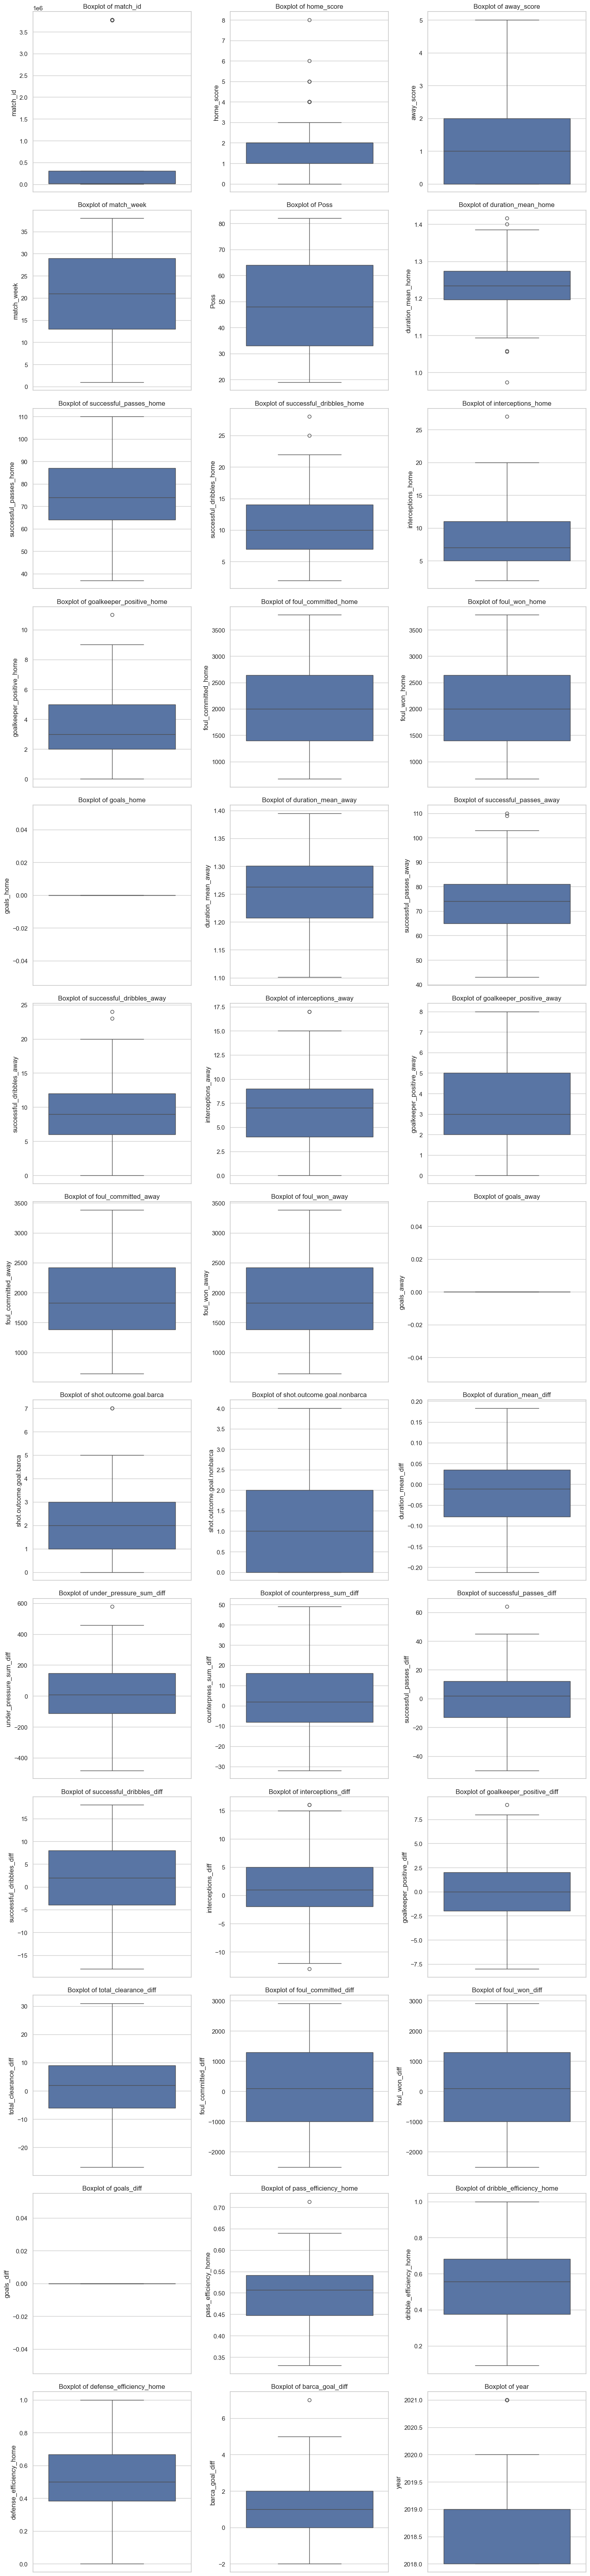

In [41]:
def show_boxplots(df):
    num_cols = df.select_dtypes(include='number').columns
    n = len(num_cols)

    # Hitung baris & kolom grid
    ncols = 3  # jumlah kolom subplot
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5*nrows))
    axes = axes.flatten()

    for i, col in enumerate(num_cols):
        sns.boxplot(y=df[col], ax=axes[i])
        axes[i].set_title(f'Boxplot of {col}')

    # Hapus axis kosong
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

show_boxplots(df_merged)

In [42]:
df_merged.head(10)

# drop result


,match_id,match_date,kick_off,home_score,away_score,match_week,home_team.home_team_name,away_team.away_team_name,stadium.name,referee.name,home_team.managers_name,home_team.managers_country,home_team.managers_dob,away_team.managers_name,away_team.managers_country,away_team.managers_dob,Poss,Result,possession_team.name_home,duration_mean_home,under_pressure_sum_home,counterpress_sum_home,successful_passes_home,successful_dribbles_home,interceptions_home,goalkeeper_positive_home,total_clearance_home,foul_committed_home,foul_won_home,goals_home,is_home_home,is_away_home,possession_team.name_away,duration_mean_away,under_pressure_sum_away,counterpress_sum_away,successful_passes_away,successful_dribbles_away,interceptions_away,goalkeeper_positive_away,total_clearance_away,foul_committed_away,foul_won_away,goals_away,is_home_away,is_away_away,shot.outcome.goal.barca,shot.outcome.goal.nonbarca,duration_mean_diff,under_pressure_sum_diff,counterpress_sum_diff,successful_passes_diff,successful_dribbles_diff,interceptions_diff,goalkeeper_positive_diff,total_clearance_diff,foul_committed_diff,foul_won_diff,goals_diff,pass_efficiency_home,dribble_efficiency_home,defense_efficiency_home,barca_goal_diff,year
0,9742,2018-01-07,16:15:00.000,3,0,18,Barcelona,Levante UD,Spotify Camp Nou,NaN,Ernesto Valverde Tejedor,Spain,1964-02-09,Juan Ramón López Muñiz,Spain,1968-11-02,29.0,Win,Barcelona,1.181638,434,54,64,15,18,4,10,2615,2615,0,True,False,Levante UD,1.136273,354,51,54,6,8,6,19,1104,1104,0,False,True,3.0,0.0,0.045365,80,3,10,9,10,-2,-9,1511,1511,0,0.542373,0.714285,0.400000,3.0,2018
1,9754,2018-01-14,20:45:00.000,2,4,19,Real Sociedad,Barcelona,Reale Arena,José Luis González González,Eusebio Sacristán Mena,Spain,1964-04-13,Ernesto Valverde Tejedor,Spain,1964-02-09,50.0,Lose,Real Sociedad,1.263976,468,53,84,10,9,4,17,1861,1861,0,True,False,Barcelona,1.275084,459,52,56,9,6,3,10,1827,1827,0,False,True,4.0,2.0,-0.011109,9,1,28,1,3,1,7,34,34,0,0.600000,0.526316,0.571428,2.0,2018
2,9765,2018-01-21,20:45:00.000,0,5,20,Real Betis,Barcelona,Estadio Benito Villamarín,NaN,Eder Sarabia Armesto,Spain,1981-01-12,Ernesto Valverde Tejedor,Spain,1964-02-09,52.0,Lose,Real Betis,1.217708,331,35,82,3,10,3,8,1761,1761,0,True,False,Barcelona,1.279247,488,67,74,20,13,5,5,2107,2107,0,False,True,5.0,0.0,-0.061539,-157,-32,8,-17,-3,-2,3,-346,-346,0,0.525641,0.130435,0.375000,5.0,2018
3,9774,2018-01-28,20:45:00.000,2,1,21,Barcelona,Deportivo Alavés,Spotify Camp Nou,Ignacio Iglesias Villanueva,Ernesto Valverde Tejedor,Spain,1964-02-09,Abelardo Fernández Antuña,Spain,1970-04-19,23.0,Win,Barcelona,1.273502,422,74,95,16,20,6,31,2697,2697,0,True,False,Deportivo Alavés,1.344273,186,45,78,11,5,4,17,814,814,0,False,True,2.0,1.0,-0.070771,236,29,17,5,15,2,14,1883,1883,0,0.549133,0.592592,0.599999,1.0,2018
4,9783,2018-02-04,16:15:00.000,1,1,22,Espanyol,Barcelona,RCDE Stadium,Jesús Gil Manzano,Enrique Sánchez Flores,Spain,1965-02-05,Ernesto Valverde Tejedor,Spain,1964-02-09,72.0,Draw,Espanyol,0.973971,214,54,79,8,5,2,13,912,912,0,True,False,Barcelona,1.185643,388,68,103,11,17,3,35,2351,2351,0,False,True,1.0,1.0,-0.211672,-174,-14,-24,-3,-12,-1,-22,-1439,-1439,0,0.434066,0.421052,0.399999,0.0,2018
5,9794,2018-02-11,16:15:00.000,0,0,23,Barcelona,Getafe,Spotify Camp Nou,David Fernández Borbalan,Ernesto Valverde Tejedor,Spain,1964-02-09,José Bordalás Jiménez,Spain,1964-03-05,21.0,Draw,Barcelona,1.302541,384,74,109,12,27,5,20,2824,2824,0,True,False,Getafe,1.277433,129,25,76,3,11,8,1,703,703,0,False,True,0.0,0.0,0.025108,255,49,33,9,16,-3,19,2121,2121,0,0.589189,0.799999,0.384615,0.0,2018
6,9799,2018-02-17,16:15:00.000,0,2,24,Eibar,Barcelona,Estadio Municipal de Ipurúa,Alejandro José Hernández Hernández,José Luis Mendilibar Etxebarria,Spain,1961-03-14,Ernesto Valverde Tejedor,Spain,1964-02-09,54.0,Lose,Eibar,1.234258,333,52,91,7,20,3,28,1768,1768,0,True,False,Barcelona,1.326094,332,50,97,9,14,4,5,1887,1887,0,False,True,2.0,0.0,-0.091836,1,2,-6,-2,6,-1,23,-119,-119,0,0.484043,0.437500,0.4

In [43]:
def count_outliers(df):
    outlier_counts = {}
    for col in df.select_dtypes(include=[np.number]).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outlier_counts[col] = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    return outlier_counts

outliers = count_outliers(df_merged)
outliers_df = pd.DataFrame.from_dict(outliers, orient='index', columns=['Outlier Count'])
outliers_df = outliers_df.sort_values(by='Outlier Count', ascending=False)

print(outliers_df)


                            Outlier Count
home_score                             12
match_id                                9
year                                    7
duration_mean_home                      5
interceptions_diff                      3
shot.outcome.goal.barca                 2
successful_dribbles_away                2
interceptions_away                      2
successful_passes_away                  2
successful_dribbles_home                2
goalkeeper_positive_home                1
pass_efficiency_home                    1
interceptions_home                      1
goalkeeper_positive_diff                1
barca_goal_diff                         1
successful_passes_diff                  1
under_pressure_sum_diff                 1
defense_efficiency_home                 0
dribble_efficiency_home                 0
goals_diff                              0
counterpress_sum_diff                   0
foul_won_diff                           0
foul_committed_diff               

In [44]:
import os
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import mutual_info_classif

In [45]:
drop_patterns = [
    r'\bplayer\b', r'\bmanagers\b', r'\breferee\b', r'\bstadium\b', r'\bvenue\b',
    r'name', r'\bcoach\b', r'\barb\b', r'\bcountry\b', r'\bcity\b','kick_off',
    'year','goals_diff','goals_away','barac_goal_diff','shot.outcome.goal.barca',
    'is_home_home','is_away_home','goals_home','home_team.managers_country','away_team.managers_country',
    'home_team.managers_dob','away_team.managers_dob'
]
protected_keep = {'match_id'}  # tetap simpan buat join/submit kalau ada

cols_to_drop = []
for c in df_merged.columns:
    if c in protected_keep:
        continue
    # buang semua object berbau nama/string panjang
    if df_merged[c].dtype == 'O':
        if any(re.search(pat, c, re.I) for pat in drop_patterns):
            cols_to_drop.append(c)

# drop obvious datetime (optional, jika ada)

time_like = [c for c in df_merged.columns if re.search(r'date|time', c, re.I)]
cols_to_drop += time_like




df_cln = df_merged.drop(columns=list(set(cols_to_drop)), errors='ignore').copy()
leak_cols = [c for c in df_cln.columns if re.search(r'(score)', c, re.I)]

df_cln = df_cln.drop(columns=leak_cols, errors='ignore')
df_cln = df_cln.dropna(axis=1, how='all')  # drop all-NaN columns
df_cln = df_cln.reset_index(drop=True)

df_cln = drop_cols_by_names(df_cln, ['match_week','Poss','goals_home','goals_home','is_home_home','is_away_home',
                                     'goals_away','is_home_away','is_away_away','shot.outcome.goal.barca','shot.outcome.goal.nonbarca','goals_diff','barca_goal_diff','year',
                                     ])
test_merged =  drop_cols_by_names(df_cln, ['match_week','Poss','goals_home','goals_home','is_home_home','is_away_home',
                                     'goals_away','is_home_away','is_away_away','shot.outcome.goal.barca','shot.outcome.goal.nonbarca','goals_diff','barca_goal_diff','year',
                                     ])

df_cln.head(10)





KeyError: "['match_week', 'Poss', 'goals_home', 'goals_home', 'is_home_home', 'is_away_home', 'goals_away', 'is_home_away', 'is_away_away', 'shot.outcome.goal.barca', 'shot.outcome.goal.nonbarca', 'goals_diff', 'barca_goal_diff', 'year'] not found in axis"

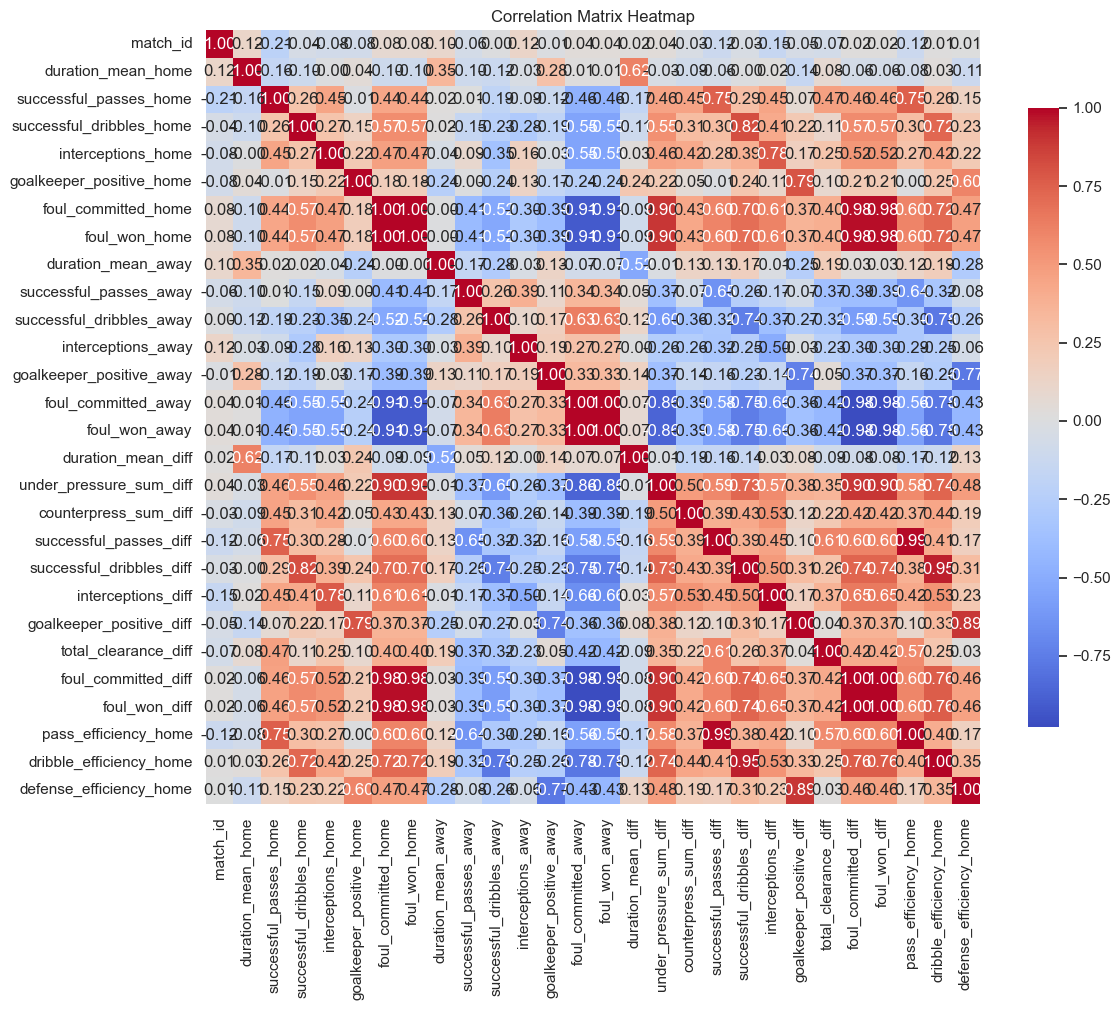

In [ ]:
# buat correlation matrix heatmap
plt.figure(figsize=(12,10))
collumns = [c for c in df_cln.select_dtypes(include=[np.number]).columns if df_cln[c].nunique() > 1]
corr = df_cln[collumns].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, f_classif

In [ ]:
df_model = df_cln.copy()

In [ ]:
le_target = LabelEncoder()
df_model['Result_encoded'] = le_target.fit_transform(df_model['Result'])

In [ ]:
numeric_features = df_model.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ['Result_encoded', 'match_id']
numeric_features = [col for col in numeric_features if col not in exclude_cols]

df_model[numeric_features] = df_model[numeric_features].fillna(df_model[numeric_features].median())
df_model.tail(10)



,match_id,Result,duration_mean_home,under_pressure_sum_home,counterpress_sum_home,successful_passes_home,successful_dribbles_home,interceptions_home,goalkeeper_positive_home,total_clearance_home,foul_committed_home,foul_won_home,duration_mean_away,under_pressure_sum_away,counterpress_sum_away,successful_passes_away,successful_dribbles_away,interceptions_away,goalkeeper_positive_away,total_clearance_away,foul_committed_away,foul_won_away,duration_mean_diff,under_pressure_sum_diff,counterpress_sum_diff,successful_passes_diff,successful_dribbles_diff,interceptions_diff,goalkeeper_positive_diff,total_clearance_diff,foul_committed_diff,foul_won_diff,pass_efficiency_home,dribble_efficiency_home,defense_efficiency_home,Result_encoded
75,303634,Lose,1.255000,490,61,93,22,11,2,34,3013,3013,1.245325,212,39,68,6,2,2,18,740,740,0.009675,278,22,25,16,9,0,16,2273,2273,0.577640,0.785714,0.499999,1
76,3773547,Win,1.151027,273,49,78,9,8,6,22,2819,2819,1.289671,218,39,76,2,7,0,14,1213,1213,-0.138644,55,10,2,7,1,6,8,1606,1606,0.506493,0.818181,0.999998,2
77,3773428,Win,1.333145,194,32,60,6,2,7,11,672,672,1.150222,359,41,110,17,15,6,38,3185,3185,0.182924,-165,-9,-50,-11,-13,1,-27,-2513,-2513,0.352941,0.260869,0.538461,2
78,3773552,Lose,1.344651,284,57,60,9,5,1,6,1316,1316,1.263011,410,52,69,15,7,5,17,2859,2859,0.081640,-126,5,-9,-6,-2,-4,-11,-1543,-1543,0.465116,0.375000,0.166666,1
79,3773565,Lose,1.400499,201,27,51,7,2,2,14,1093,1093,1.305353,307,31,63,5,10,7,7,2677,2677,0.095145,-106,-4,-12,2,-8,-5,7,-1584,-1584,0.447368,0.583333,0.222222,1
80,3773415,Draw,1.158711,327,49,82,14,19,5,23,3250,3250,1.241679,182,30,73,5,4,1,7,707,707,-0.082967,145,19,9,9,15,4,16,2543,2543,0.529032,0.736842,0.833332,0
81,3764440,Win,1.319059,340,43,49,13,14,1,16,2615,2615,1.343129,277,48,70,3,12,4,11,1541,1541,-0.024070,63,-5,-21,10,2,-3,5,1074,1074,0.411765,0.812499,0.200000,2
82,3773665,Lose,1.239459,349,57,76,4,7,4,15,1572,1572,1.288255,350,43,76,14,8,5,17,2613,2613,-0.048796,-1,14,0,-10,-1,-1,-2,-1041,-1041,0.500000,0.222222,0.444444,1
83,3773369,Win,1.194517,645,75,66,20,5,2,13,3273,3273,1.292670,387,67,57,13,6,0,16,1525,1525,-0.098153,258,8,9,7,-1,2,-3,1748,1748,0.536585,0.606060,0.999995,2
84,3773586,Lose,1.192491,502,40,69,8,8,3,24,3108,3108,1.230249,234,59,59,11,8,3,19,841,841,-0.037758,268,-19,10,-3,0,0,5,2267,2267,0.539062,0.421052,0.499999,1


In [ ]:
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.01)
X_temp = df_model[numeric_features].copy()
selector.fit(X_temp)
high_var_features = X_temp.columns[selector.get_support()].tolist()

X_fs = df_model[high_var_features].copy()
y_fs = df_model['Result_encoded'].copy()

mi_scores = mutual_info_classif(X_fs, y_fs, random_state=42)
mi_df = pd.DataFrame({
    'feature': high_var_features,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

print("\nTop 20 Features by Mutual Information:")
print(mi_df.head(20))




Top 20 Features by Mutual Information:
                     feature  mi_score
5              foul_won_home  0.252400
12   under_pressure_sum_diff  0.246453
1   successful_dribbles_home  0.246437
4        foul_committed_home  0.243564
21   dribble_efficiency_home  0.196664
20             foul_won_diff  0.196007
19       foul_committed_diff  0.196007
15  successful_dribbles_diff  0.177106
9   goalkeeper_positive_away  0.147530
10       foul_committed_away  0.143185
11             foul_won_away  0.136176
7   successful_dribbles_away  0.132518
2         interceptions_home  0.102033
13     counterpress_sum_diff  0.051432
16        interceptions_diff  0.046363
18      total_clearance_diff  0.034812
6     successful_passes_away  0.029972
3   goalkeeper_positive_home  0.014216
22   defense_efficiency_home  0.000538
0     successful_passes_home  0.000000


In [ ]:
K_BEST = min(30, len(high_var_features))  # Pilih top 30 atau semua jika kurang
selected_features = mi_df.head(K_BEST)['feature'].tolist()

print(f"\n✅ Selected {len(selected_features)} features for modeling")


✅ Selected 23 features for modeling


In [ ]:
X = df_model[selected_features].copy()
y = df_model['Result_encoded'].copy()

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTrain set distribution:\n{pd.Series(y_train).value_counts()}")
print(f"\nTest set distribution:\n{pd.Series(y_test).value_counts()}")

# Scaling dengan RobustScaler (lebih robust terhadap outliers)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train set size: 68
Test set size: 17

Train set distribution:
Result_encoded
2    33
1    21
0    14
Name: count, dtype: int64

Test set distribution:
Result_encoded
2    8
1    5
0    4
Name: count, dtype: int64


In [ ]:
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=4,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=4,
        subsample=0.8,
        random_state=42
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=1,
        random_state=42,
        eval_metric='mlogloss'
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        num_leaves=31,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        random_state=42,
        verbose=-1
    )
}

In [ ]:
results = []
for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training {name}...")
    print('='*60)
    
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    # Calculate F1-Macro scores
    f1_train = f1_score(y_train, y_pred_train, average='macro')
    f1_test = f1_score(y_test, y_pred_test, average='macro')
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, 
                                cv=5, scoring='f1_macro', n_jobs=-1)
    
    results.append({
        'Model': name,
        'F1-Macro (Train)': f1_train,
        'F1-Macro (Test)': f1_test,
        'CV F1-Macro (Mean)': cv_scores.mean(),
        'CV F1-Macro (Std)': cv_scores.std()
    })
    
    print(f"\nF1-Macro Train: {f1_train:.4f}")
    print(f"F1-Macro Test: {f1_test:.4f}")
    print(f"CV F1-Macro: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    
    # Classification report
    print(f"\n{name} - Classification Report (Test Set):")
    print(classification_report(y_test, y_pred_test, 
                                target_names=le_target.classes_))

# Display results summary
results_df = pd.DataFrame(results).sort_values('F1-Macro (Test)', ascending=False)
print("\n" + "="*80)
print("MODEL COMPARISON - F1-MACRO SCORES")
print("="*80)
print(results_df.to_string(index=False))


Training Random Forest...

F1-Macro Train: 0.8399
F1-Macro Test: 0.5185
CV F1-Macro: 0.4684 (+/- 0.1303)

Random Forest - Classification Report (Test Set):
              precision    recall  f1-score   support

        Draw       0.00      0.00      0.00         4
        Lose       1.00      0.80      0.89         5
         Win       0.60      0.75      0.67         8

    accuracy                           0.59        17
   macro avg       0.53      0.52      0.52        17
weighted avg       0.58      0.59      0.58        17


Training Gradient Boosting...

F1-Macro Train: 1.0000
F1-Macro Test: 0.3905
CV F1-Macro: 0.5440 (+/- 0.1555)

Gradient Boosting - Classification Report (Test Set):
              precision    recall  f1-score   support

        Draw       0.00      0.00      0.00         4
        Lose       1.00      0.40      0.57         5
         Win       0.50      0.75      0.60         8

    accuracy                           0.47        17
   macro avg       0.50  

C:\Users\sayyi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:199: UserWarning: [22:08:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



F1-Macro Train: 0.9697
F1-Macro Test: 0.4605
CV F1-Macro: 0.4688 (+/- 0.0936)

XGBoost - Classification Report (Test Set):
              precision    recall  f1-score   support

        Draw       0.00      0.00      0.00         4
        Lose       1.00      0.60      0.75         5
         Win       0.55      0.75      0.63         8

    accuracy                           0.53        17
   macro avg       0.52      0.45      0.46        17
weighted avg       0.55      0.53      0.52        17


Training LightGBM...


C:\Users\sayyi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\sayyi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



F1-Macro Train: 0.9740
F1-Macro Test: 0.4127
CV F1-Macro: 0.4306 (+/- 0.0657)

LightGBM - Classification Report (Test Set):
              precision    recall  f1-score   support

        Draw       0.00      0.00      0.00         4
        Lose       1.00      0.40      0.57         5
         Win       0.60      0.75      0.67         8

    accuracy                           0.47        17
   macro avg       0.53      0.38      0.41        17
weighted avg       0.58      0.47      0.48        17


MODEL COMPARISON - F1-MACRO SCORES
            Model  F1-Macro (Train)  F1-Macro (Test)  CV F1-Macro (Mean)  CV F1-Macro (Std)
    Random Forest          0.839854         0.518519            0.468366           0.130330
          XGBoost          0.969720         0.460526            0.468757           0.093583
         LightGBM          0.974026         0.412698            0.430577           0.065748
Gradient Boosting          1.000000         0.390476            0.544021           0.15546

In [ ]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"\n🏆 Best Single Model: {best_model_name}")
print(f"F1-Macro (Test): {results_df.iloc[0]['F1-Macro (Test)']:.4f}")

# Create Voting Ensemble of top 3 models
top_3_models = [(name, models[name]) for name in results_df.head(3)['Model'].tolist()]

voting_clf = VotingClassifier(
    estimators=top_3_models,
    voting='soft',
    n_jobs=-1
)

print("\n" + "="*60)
print("Training Voting Ensemble (Top 3 Models)...")
print("="*60)

voting_clf.fit(X_train_scaled, y_train)
y_pred_ensemble = voting_clf.predict(X_test_scaled)

f1_ensemble = f1_score(y_test, y_pred_ensemble, average='macro')
print(f"\n✨ Ensemble F1-Macro (Test): {f1_ensemble:.4f}")

print("\nEnsemble - Classification Report (Test Set):")
print(classification_report(y_test, y_pred_ensemble, 
                           target_names=le_target.classes_))




🏆 Best Single Model: Random Forest
F1-Macro (Test): 0.5185

Training Voting Ensemble (Top 3 Models)...

✨ Ensemble F1-Macro (Test): 0.4010

Ensemble - Classification Report (Test Set):
              precision    recall  f1-score   support

        Draw       0.00      0.00      0.00         4
        Lose       1.00      0.40      0.57         5
         Win       0.55      0.75      0.63         8

    accuracy                           0.47        17
   macro avg       0.52      0.38      0.40        17
weighted avg       0.55      0.47      0.47        17



C:\Users\sayyi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Top 20 Feature Importances (LightGBM):
                     feature  importance
5              foul_won_diff          75
15      total_clearance_diff          73
21    successful_passes_diff          73
13     counterpress_sum_diff          66
20        interceptions_away          62
2   successful_dribbles_home          56
16    successful_passes_away          56
18   defense_efficiency_home          52
11  successful_dribbles_away          51
14        interceptions_diff          50
7   successful_dribbles_diff          50
22  goalkeeper_positive_diff          50
1    under_pressure_sum_diff          48
4    dribble_efficiency_home          48
0              foul_won_home          41
12        interceptions_home          27
17  goalkeeper_positive_home          23
19    successful_passes_home          22
6        foul_committed_diff          13
9        foul_committed_away          10


C:\Users\sayyi\AppData\Local\Temp\ipykernel_32908\2396789945.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp_df.head(top_n),


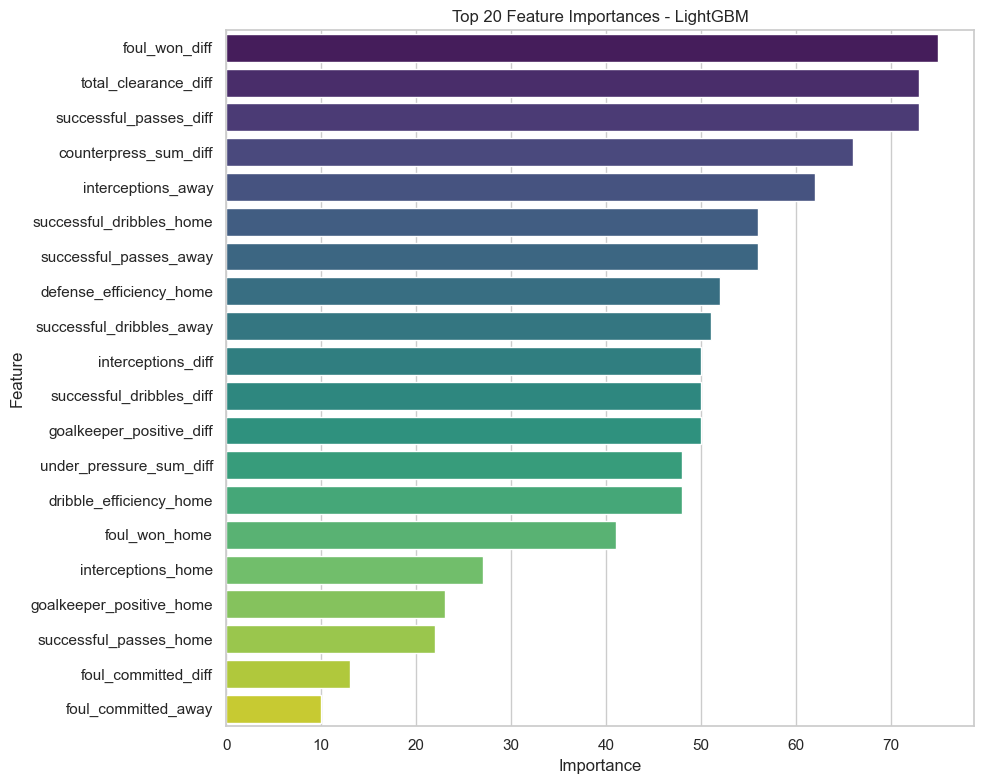

In [ ]:
best_tree_model = None
for name in ['LightGBM', 'XGBoost', 'Random Forest', 'Gradient Boosting']:
    if name in models:
        best_tree_model = models[name]
        best_tree_name = name
        break

if best_tree_model and hasattr(best_tree_model, 'feature_importances_'):
    importances = best_tree_model.feature_importances_
    feature_imp_df = pd.DataFrame({
        'feature': selected_features,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    print(f"\nTop 20 Feature Importances ({best_tree_name}):")
    print(feature_imp_df.head(20))
    
    # Plot feature importance
    plt.figure(figsize=(10, 8))
    top_n = 20
    sns.barplot(data=feature_imp_df.head(top_n), 
                y='feature', x='importance', palette='viridis')
    plt.title(f'Top {top_n} Feature Importances - {best_tree_name}')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

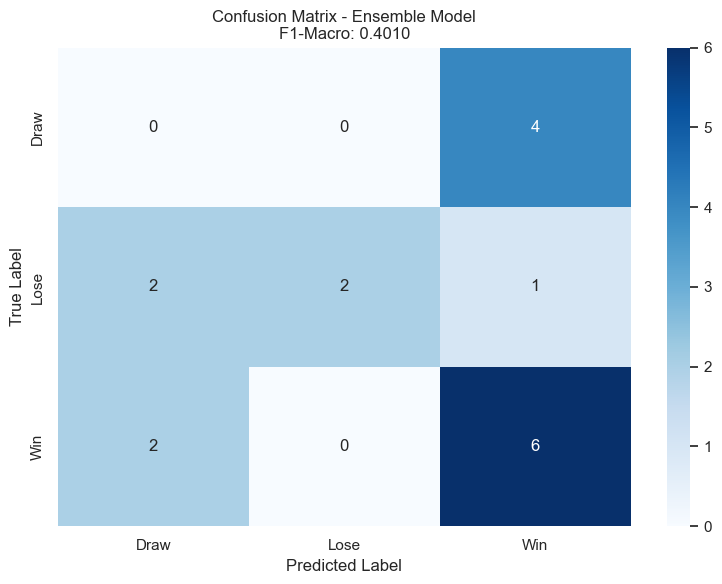

In [ ]:
cm = confusion_matrix(y_test, y_pred_ensemble)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_target.classes_, 
            yticklabels=le_target.classes_)
plt.title(f'Confusion Matrix - Ensemble Model\nF1-Macro: {f1_ensemble:.4f}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*60)
print("Hyperparameter Tuning for Best Model...")
print("="*60)

param_grid = {
    'n_estimators': [150, 200, 250],
    'learning_rate': [0.03, 0.05, 0.07],
    'max_depth': [4, 5, 6],
    'num_leaves': [25, 31, 40],
    'min_child_samples': [15, 20, 25]
}

lgbm_tuned = lgb.LGBMClassifier(
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

grid_search = GridSearchCV(
    lgbm_tuned,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV F1-Macro: {grid_search.best_score_:.4f}")

# Evaluate tuned model
y_pred_tuned = grid_search.best_estimator_.predict(X_test_scaled)
f1_tuned = f1_score(y_test, y_pred_tuned, average='macro')

print(f"Tuned Model F1-Macro (Test): {f1_tuned:.4f}")

print("\nTuned Model - Classification Report:")
print(classification_report(y_test, y_pred_tuned, 
                           target_names=le_target.classes_))


Hyperparameter Tuning for Best Model...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits

Best parameters: {'learning_rate': 0.07, 'max_depth': 4, 'min_child_samples': 25, 'n_estimators': 250, 'num_leaves': 25}
Best CV F1-Macro: 0.4957
Tuned Model F1-Macro (Test): 0.3305

Tuned Model - Classification Report:
              precision    recall  f1-score   support

        Draw       0.00      0.00      0.00         4
        Lose       0.50      0.20      0.29         5
         Win       0.67      0.75      0.71         8

    accuracy                           0.41        17
   macro avg       0.39      0.32      0.33        17
weighted avg       0.46      0.41      0.42        17



C:\Users\sayyi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
final_model = grid_search.best_estimator_ if f1_tuned > f1_ensemble else voting_clf
final_f1 = max(f1_tuned, f1_ensemble)
final_model_name = "Tuned LightGBM" if f1_tuned > f1_ensemble else "Voting Ensemble"

print("\n" + "="*80)
print("FINAL MODEL SELECTION")
print("="*80)
print(f"Selected Model: {final_model_name}")
print(f"F1-Macro Score: {final_f1:.4f}")


FINAL MODEL SELECTION
Selected Model: Voting Ensemble
F1-Macro Score: 0.4010


In [ ]:
test_merged = test_data.merge(
    aggregated_features,
    on='match_id',
    how='left'
)

In [ ]:
test_cln = test_merged.drop(columns=list(set(cols_to_drop)), errors='ignore')
test_cln = test_cln.drop(columns=leak_cols, errors='ignore')
test_cln = test_cln.dropna(axis=1, how='all')

In [ ]:
missing_cols = [c for c in selected_features if c not in test_cln.columns]
for c in missing_cols:
    test_cln[c] = 0  # isi 0 untuk fitur yang gak ada di test

X_test_sub = test_cln[selected_features].fillna(df_model[selected_features].median())


In [ ]:
import pickle
with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open('final_model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('label_encoder.pkl', 'rb') as f:
    le_target = pickle.load(f)

# 5️⃣ Transform dan prediksi
X_test_scaled = scaler.transform(X_test_sub)
y_pred = model.predict(X_test_scaled)
y_pred_labels = le_target.inverse_transform(y_pred)

# 6️⃣ Buat file submission
submission = pd.DataFrame({
    'match_id': test_cln['match_id'],
    'Result': y_pred_labels
})
submission.to_csv('final_submission.csv', index=False)

print("\n✅ Submission berhasil dibuat: final_submission.csv")
print("Distribusi prediksi:")
print(submission['Result'].value_counts())


✅ Submission berhasil dibuat: final_submission.csv
Distribusi prediksi:
Result
Lose    36
Name: count, dtype: int64


C:\Users\sayyi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:


# Save model
with open('final_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le_target, f)

# Save feature list
with open('selected_features.pkl', 'wb') as f:
    pickle.dump(selected_features, f)

print("\n✅ Model artifacts saved:")
print("   - final_model.pkl")
print("   - scaler.pkl")
print("   - label_encoder.pkl")
print("   - selected_features.pkl")


✅ Model artifacts saved:
   - final_model.pkl
   - scaler.pkl
   - label_encoder.pkl
   - selected_features.pkl


In [ ]:
test_merged.to_csv('test_data_processed.csv', index=False)

In [ ]:

def generate_submission(test_data_path, output_path='submission.csv'):
    # Load test data
    test_df = pd.read_csv(test_data_path)
    
    # Load saved artifacts
    with open('final_model.pkl', 'rb') as f:
        model = pickle.load(f)
    with open('scaler.pkl', 'rb') as f:
        scaler = pickle.load(f)
    with open('label_encoder.pkl', 'rb') as f:
        le = pickle.load(f)
    with open('selected_features.pkl', 'rb') as f:
        features = pickle.load(f)
    
    # Prepare test features (same preprocessing as training)
    X_test_sub = test_df[features].copy()
    X_test_sub = X_test_sub.fillna(X_test_sub.median())
    X_test_scaled = scaler.transform(X_test_sub)
    
    # Generate predictions
    predictions = model.predict(X_test_scaled)
    predictions_labels = le.inverse_transform(predictions)
    
    # Create submission dataframe
    submission = pd.DataFrame({
        'match_id': test_df['match_id'],
        'Result': predictions_labels
    })
    
    # Save submission
    submission.to_csv(output_path, index=False)
    print(f"\n✅ Submission file saved to: {output_path}")
    print(f"   Shape: {submission.shape}")
    print(f"\nPrediction distribution:")
    print(submission['Result'].value_counts())
    
    return submission
generate_submission('test_data_processed.csv', 'final_submission.csv')